# Proteomics Dataset. 
**Notes for this dataset 10.21.25**
- This is the original dataset used for chapter IV of my dissertation. The python code below has been tested and revised from its original creation ~Spring 2024.
**In this dataset:**
- Only proteins which were present in 100% of the samples between two timepoints were retained for analysis.
- Relative abundance values (log2 fold change) for proteins were assessed at two or three timepoints (Wilcoxon signed rank test or Friedman test, respectively).
- Significantly up- and downregulated proteins (P<0.1) were identified and entered into the [STRING](https://string-db.org/).
- Protein protein interaction (PPI) networks were generated and grouped according to shared biological pathways (GO terms); proteins associated with the acute-phase immune response were identified based on pre-existing hypotheses. 

**Future Steps:**
1) Analyze the dataset inclusive of proteins that were present in >85% of samples as opposed of only those present in 100% of the samples
2) Perform additional analyses and visuals of protein-protein interaction networks using [Cytoscape](https://www.youtube.com/watch?v=Ohf9IPUJ82w).

**Data Cleaning**
Orient the data to proper tabular format (rows=observations, columns= subject, time, proteins)
Remove missing observations for each protein by selected time point comparisons


1) Calculate log2 fold change for all proteins at each time point (BL, Rec2, Rec21)
2) Run Wilcoxon Signed test (dependent samples t-test, nonparametric) BL to Rec2 and BL to Rec21
3) Run Friedman test (1x3 RM ANOVA, nonparametric) for all proteins present at all 3 timepoints.

**False Discovery Rate (FDR)**
Similar to Family-wise Error rate (100s to 1000s of proteins, genes being analyzed at alpha=0.05 will end in large number of false positives (Type I error). 
**Note:** 
- Since this was a pilot investigation with low sample size (n=7 adult females), alpha significance level was set at 0.1 (unadjusted) in line with exsisting proteomics research. 

- Bonferroni and other multiple comparison methods are too conservative to handle this number of comparisons.
FDR methods are less conservative and are accepted practice for detecting significant expression changes in proteins and other similar systems biology approaches. 


- [Here](https://www.publichealth.columbia.edu/research/population-health-methods/false-discovery-rate
) is a good overview of what False Discovery Rate is



- [Here](https://www.youtube.com/watch?v=K8LQSvtjcEo) is an excellent tutorial by StatQuest (UNC-Chapel Hill Genetics Department) on how to run FDR and what it actually is (Benjamini-Hochberg is commonly used method to correct p-value for FDR)



[Here](https://ab604.github.io/docs/bspr_workshop_2018/transform.html) is an example of someone dealing with protein FC in R Studio:


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.stats.multitest as smm

In [2]:
df= pd.read_csv("Gooding Proteomics dataset 1.17.24.csv")

df.columns=df.columns.str.lower()

df.head()

,accession,s10,s10.1,s10.2,s11,s11.1,s11.2,s18,s18.1,s18.2,...,s19.2,s23,s23.1,s23.2,s24,s24.1,s24.2,s25,s25.1,s25.2
0,Time,BL,Rec2,Rec21,BL,Rec2,Rec21,BL,Rec2,Rec21,...,Rec21,BL,Rec2,Rec21,BL,Rec2,Rec21,BL,Rec2,Rec21
1,A0A075B6R2,NaN,80.3,NaN,NaN,NaN,NaN,77.9,157,163.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,135.7,1085.1,400.3
2,A0A075B6S5,52.8,55,60.9,NaN,48.1,50.5,72.5,84.9,154.3,...,58.4,88.6,96.6,195.7,48.5,85.7,59.1,119.4,453.2,144.1
3,A0A0B4J1V0,105.3,79.5,108.8,121,77.9,70,80.7,98.5,99.9,...,77.5,130.6,132.4,157.1,42.3,51.2,62.3,71.8,235.8,171.5
4,A0A0B4J1Y9,NaN,41.3,NaN,162.3,128.5,185,140.1,180.4,206.1,...,94.1,112.1,95.7,105.4,43.9,59.5,62.8,79.2,NaN,142.6


In [3]:
df.columns

Index(['accession', 's10', 's10.1', 's10.2', 's11', 's11.1', 's11.2', 's18',
       's18.1', 's18.2', 's19', 's19.1', 's19.2', 's23', 's23.1', 's23.2',
       's24', 's24.1', 's24.2', 's25', 's25.1', 's25.2'],
      dtype='object')

In [4]:
col_names = list(df['accession'])

In [5]:
df_transposed = df.drop(columns=['accession']).T.copy()
df_transposed.reset_index()
df_transposed.columns = col_names

df_transposed.reset_index(inplace=True)

df_transposed.rename(columns={'index':'subject_id'}, inplace=True)
df_transposed.columns = df_transposed.columns.str.lower()
df_transposed.head()

,subject_id,time,a0a075b6r2,a0a075b6s5,a0a0b4j1v0,a0a0b4j1y9,a0a0b4j2d9,a0a0c4dh25,a0a0c4dh38,a0a0c4dh72,...,q9y4e8,q9y570-4,p02768,p01008,p06396,p02753,a0a0a0mrq5,p62979,p02788,q15843
0,s10,BL,NaN,52.8,105.3,NaN,NaN,55.7,NaN,56.6,...,70.4,94.2,78.5,55.6,85,52.5,153.4,41.5,51.1,119.5
1,s10.1,Rec2,80.3,55,79.5,41.3,NaN,72.1,224.9,73.1,...,87,102.7,102.4,117.4,77.5,73.6,103.3,175.9,NaN,124.7
2,s10.2,Rec21,NaN,60.9,108.8,NaN,NaN,94.4,NaN,83.4,...,NaN,115.6,95.2,103.7,75.4,56.2,107.5,74.9,77.1,103.8
3,s11,BL,NaN,NaN,121,162.3,NaN,52,NaN,NaN,...,57.3,146.4,76.1,130.5,79.3,80.3,131.5,55.7,NaN,63.3
4,s11.1,Rec2,NaN,48.1,77.9,128.5,223.9,68.4,NaN,21.5,...,95.7,122.3,95.2,142.2,83.7,91.5,70.9,257.9,81.2,131.6


In [6]:
### need to fix subject_id names

## easier way to 'fix' subject_id values
df_transposed['subject_id'] = df_transposed['subject_id'].str.replace('.1', '').str.replace('.2', '')

### older method to replace specific values by applying a map
df_transposed.head(21)
mapping = {
    's10' : 's10',
    's10.1': 's10', 
    's10.2': 's10', 
    's11': 's11', 
    's11.1': 's11', 
    's11.2': 's11', 
    's18' : 's18', 
    's18.1': 's18',
    's18.2': 's18', 
    's19' : 's19', 
    's19.1': 's19', 
    's19.2': 's19', 
    's23' : 's23', 
    's23.1': 's23',
    's23.2': 's23', 
    's24' : 's24', 
    's24.1': 's24', 
    's24.2': 's24',
    's25' : 's25',
    's25.1': 's25',
    's25.2': 's25'
}

# df_transposed['subject_id'] = df_transposed['subject_id'].map(mapping)

df_transposed.head(21)

,subject_id,time,a0a075b6r2,a0a075b6s5,a0a0b4j1v0,a0a0b4j1y9,a0a0b4j2d9,a0a0c4dh25,a0a0c4dh38,a0a0c4dh72,...,q9y4e8,q9y570-4,p02768,p01008,p06396,p02753,a0a0a0mrq5,p62979,p02788,q15843
0,s10,BL,NaN,52.8,105.3,NaN,NaN,55.7,NaN,56.6,...,70.4,94.2,78.5,55.6,85,52.5,153.4,41.5,51.1,119.5
1,s10,Rec2,80.3,55,79.5,41.3,NaN,72.1,224.9,73.1,...,87,102.7,102.4,117.4,77.5,73.6,103.3,175.9,NaN,124.7
2,s10,Rec21,NaN,60.9,108.8,NaN,NaN,94.4,NaN,83.4,...,NaN,115.6,95.2,103.7,75.4,56.2,107.5,74.9,77.1,103.8
3,s11,BL,NaN,NaN,121,162.3,NaN,52,NaN,NaN,...,57.3,146.4,76.1,130.5,79.3,80.3,131.5,55.7,NaN,63.3
4,s11,Rec2,NaN,48.1,77.9,128.5,223.9,68.4,NaN,21.5,...,95.7,122.3,95.2,142.2,83.7,91.5,70.9,257.9,81.2,131.6
5,s11,Rec21,NaN,50.5,70,185,209.6,82.8,NaN,41.4,...,113.8,156.4,120.9,139.8,129.8,126.3,106.6,128.3,150.2,140.7
6,s18,BL,77.9,72.5,80.7,140.1,NaN,94.2,182.9,88.5,...,418.7,121.2,98,101.8,68.2,163.5,75.6,190.1,86.3,122
7,s18,Rec2,157,84.9,98.5,180.4,NaN,83.6,NaN,101.6,...,81.2,79,96.7,48.5,78.2,55.7,82.8,88,NaN,109.6
8,s18,Rec21,163.8,154.3,99.9,206.1,NaN,189,NaN,167.5,...,160.8,117.6,122.1,144.8,159.7,590.3,40.3,145.6,NaN,177.6
9,s19,BL,NaN,109.9,63.5,129.4,339.4,155.4,NaN,119,...,115.8,144.9,86.7,111.7,92.6,71.6,74.2,222.5,192.1,81


In [7]:
df_transposed.rename(columns={'a0a0a0mrq5':'Q06830'}, inplace=True)

In [8]:
### check protein col (accession) 
## Protein peroxiredoxin-1 is not in final merge of friedman

## Q06830 might be a0a0a0mrq5

## Make df columns for analysis

1) BL to Rec2

2) Bl to Rec21

3) All three time points

**remove all ros with NaN data**

In [9]:
### isolate cols of all proteins in dataset
protein_cols = np.array(df_transposed.columns[2:])

protein_cols

df_transposed[protein_cols]=df_transposed[protein_cols].apply(pd.to_numeric, errors='coerce')

In [10]:
df_transposed.shape

(21, 382)

In [11]:
subject_list = ['S10', 'S11', 'S18', 'S19', 'S23', 'S24', 'S25']

## list of subjects in case I need to add somewhere

In [12]:
### isolate DFs of each timepoint. will determine log2 foldchange from BL_df abundance values
df_BL= df_transposed[df_transposed['time']=='BL'].copy()

df_Rec2=df_transposed[df_transposed['time']=='Rec2'].copy()
df_Rec2['subject']=subject_list ## redundant now but was previous was of fixing issues in subject_id values at different timepoints

df_Rec21=df_transposed[df_transposed['time']=='Rec21'].copy()
df_Rec21['subject']=subject_list ## redundant now but was previous was of fixing issues in subject_id values at different timepoints


In [13]:
df_BL[protein_cols].count()

a0a075b6r2    2
a0a075b6s5    6
a0a0b4j1v0    7
a0a0b4j1y9    6
a0a0b4j2d9    2
             ..
p02753        7
Q06830        7
p62979        7
p02788        5
q15843        6
Length: 380, dtype: int64

In [14]:
df_BL_cleaned = df_BL.loc[:, df_BL.nunique(dropna=True) >= 6].copy().reset_index(drop=True)
df_BL_cleaned['time'] = ['baseline']*7
df_BL_cleaned.head(15)

,subject_id,a0a075b6s5,a0a0b4j1v0,a0a0b4j1y9,a0a0c4dh25,a0a0c4dh72,o14791-2,o14818-1,o43681,o43866,...,q9y4e8,q9y570-4,p02768,p01008,p06396,p02753,Q06830,p62979,q15843,time
0,s10,52.8,105.3,NaN,55.7,56.6,9.6,78.1,67.1,69.5,...,70.4,94.2,78.5,55.6,85.0,52.5,153.4,41.5,119.5,baseline
1,s11,NaN,121.0,162.3,52.0,NaN,NaN,91.2,74.6,NaN,...,57.3,146.4,76.1,130.5,79.3,80.3,131.5,55.7,63.3,baseline
2,s18,72.5,80.7,140.1,94.2,88.5,60.7,92.6,69.6,39.4,...,418.7,121.2,98.0,101.8,68.2,163.5,75.6,190.1,122.0,baseline
3,s19,109.9,63.5,129.4,155.4,119.0,157.1,80.0,138.3,72.7,...,115.8,144.9,86.7,111.7,92.6,71.6,74.2,222.5,81.0,baseline
4,s23,88.6,130.6,112.1,65.6,67.8,37.4,28.9,75.5,135.1,...,76.9,82.4,108.6,105.9,88.6,40.1,70.7,24.8,NaN,baseline
5,s24,48.5,42.3,43.9,56.6,59.0,128.9,84.6,51.0,76.6,...,92.8,66.6,88.5,63.4,88.2,134.4,39.0,51.3,150.4,baseline
6,s25,119.4,71.8,79.2,111.1,118.3,73.5,54.5,92.4,111.0,...,93.3,127.2,88.3,97.0,84.9,124.3,80.7,57.1,125.9,baseline


In [15]:
df_BL_cleaned_cols = list(df_BL_cleaned)

## Data visuals and statistical analysis of protein log2 fold change from baseline (BL) to post-training (rec2)

**Steps:**
- Calculate log2 foldchange at baseline and rec2 timepoints
- Run Wilcoxon signed rank tests
    - look for p-adjusted <= 0.05, if not p-values (unadjusted) <=0.1 (exploratory data, pilot investigation)
- Identify list of proteins that have statistically significant log2 fold change from baseline
- Combine list of proteins with significant upregulation from BL to rec21 (post-recovery) or from 3-timepoint analysis (below)
- Input list of proteins into STRING database
- Build protein-protein interaction (PPI) networks of proteins with shared biological function (i.e., immune system function)

In [16]:
df_Rec2_cleaned = df_Rec2.loc[:, df_Rec2.nunique(dropna=True)>= 6].copy().reset_index(drop=True)
df_Rec2_cleaned['time'] = ['rec2']*7
df_Rec2_cleaned.shape

(7, 270)

In [17]:
cols_to_keep = list(set(df_BL_cleaned.columns) & set(df_Rec2_cleaned.columns))

# cols_to_keep

In [18]:
df_BL_Rec2_cleaned = pd.concat([df_BL_cleaned[cols_to_keep], df_Rec2_cleaned[cols_to_keep]], ignore_index=True)

df_BL_Rec2_cleaned.head(15)

,p02652,p05155-3,p02042,p00915,p49773,p53396-1,q06033-1,p00558,p40925-3,p16157-14,...,a0a0b4j1y9,p13671,p37840-1,p68402-1,p68036-3,p06703,q9y4e8,p01031,p22792,p06733-1
0,58.6,29.6,73.7,86.3,64.0,61.2,78.1,94.2,65.1,71.4,...,NaN,68.3,33.2,75.2,99.7,46.9,70.4,29.0,77.6,175.7
1,106.9,41.1,83.3,121.6,90.9,112.0,62.8,47.5,142.8,90.1,...,162.3,62.3,24.3,85.4,187.4,105.2,57.3,40.7,63.6,102.5
2,114.8,83.0,162.8,99.6,62.3,94.0,141.6,97.0,122.6,102.0,...,140.1,126.4,90.2,127.7,172.9,102.9,418.7,143.9,75.4,183.5
3,152.6,31.6,63.4,101.5,94.5,72.6,244.3,156.0,145.3,109.4,...,129.4,48.4,115.7,125.7,61.1,159.9,115.8,179.3,45.0,94.3
4,75.1,32.5,79.5,75.5,40.5,106.3,77.7,62.5,47.9,95.6,...,112.1,68.1,45.8,96.3,77.7,90.9,76.9,74.0,67.2,40.3
5,87.5,124.3,87.5,52.3,103.0,102.0,54.3,57.7,63.8,83.1,...,43.9,59.9,65.3,61.8,57.3,60.7,92.8,112.9,81.6,75.4
6,74.4,106.6,112.2,92.1,152.4,112.3,92.2,96.6,37.5,60.8,...,79.2,113.3,100.6,67.2,87.3,97.7,93.3,72.7,71.8,26.0
7,97.4,140.0,112.0,129.5,61.5,20.5,60.1,136.2,184.9,97.3,...,41.3,140.5,81.7,139.4,158.1,123.0,87.0,156.3,123.4,150.0
8,78.6,124.7,148.6,110.5,54.0,84.6,140.4,112.8,173.8,85.9,...,128.5,109.5,123.8,68.2,87.1,92.0,95.7,93.6,77.2,136.7
9,103.9,87.8,107.7,70.1,71.9,89.7,137.6,90.2,128.7,105.9,...,180.4,134.1,102.4,110.1,50.2,77.9,81.2,135.2,73.2,54.2


In [19]:
### reset columns to have subject_id and time be first two cols
first_cols = ['subject_id', 'time']
other_cols = [col for col in df_BL_Rec2_cleaned.columns if col not in first_cols]

ordered_cols = [col for col in first_cols if col in df_BL_Rec2_cleaned.columns] + other_cols

df_BL_Rec2_cleaned = df_BL_Rec2_cleaned[ordered_cols]

df_BL_Rec2_cleaned.head(15)

,subject_id,time,p02652,p05155-3,p02042,p00915,p49773,p53396-1,q06033-1,p00558,...,a0a0b4j1y9,p13671,p37840-1,p68402-1,p68036-3,p06703,q9y4e8,p01031,p22792,p06733-1
0,s10,baseline,58.6,29.6,73.7,86.3,64.0,61.2,78.1,94.2,...,NaN,68.3,33.2,75.2,99.7,46.9,70.4,29.0,77.6,175.7
1,s11,baseline,106.9,41.1,83.3,121.6,90.9,112.0,62.8,47.5,...,162.3,62.3,24.3,85.4,187.4,105.2,57.3,40.7,63.6,102.5
2,s18,baseline,114.8,83.0,162.8,99.6,62.3,94.0,141.6,97.0,...,140.1,126.4,90.2,127.7,172.9,102.9,418.7,143.9,75.4,183.5
3,s19,baseline,152.6,31.6,63.4,101.5,94.5,72.6,244.3,156.0,...,129.4,48.4,115.7,125.7,61.1,159.9,115.8,179.3,45.0,94.3
4,s23,baseline,75.1,32.5,79.5,75.5,40.5,106.3,77.7,62.5,...,112.1,68.1,45.8,96.3,77.7,90.9,76.9,74.0,67.2,40.3
5,s24,baseline,87.5,124.3,87.5,52.3,103.0,102.0,54.3,57.7,...,43.9,59.9,65.3,61.8,57.3,60.7,92.8,112.9,81.6,75.4
6,s25,baseline,74.4,106.6,112.2,92.1,152.4,112.3,92.2,96.6,...,79.2,113.3,100.6,67.2,87.3,97.7,93.3,72.7,71.8,26.0
7,s10,rec2,97.4,140.0,112.0,129.5,61.5,20.5,60.1,136.2,...,41.3,140.5,81.7,139.4,158.1,123.0,87.0,156.3,123.4,150.0
8,s11,rec2,78.6,124.7,148.6,110.5,54.0,84.6,140.4,112.8,...,128.5,109.5,123.8,68.2,87.1,92.0,95.7,93.6,77.2,136.7
9,s18,rec2,103.9,87.8,107.7,70.1,71.9,89.7,137.6,90.2,...,180.4,134.1,102.4,110.1,50.2,77.9,81.2,135.2,73.2,54.2


In [20]:
## calculate log2 fold change for proteins
test_cols = df_BL_Rec2_cleaned.columns[2:]

test_cols

Index(['p02652', 'p05155-3', 'p02042', 'p00915', 'p49773', 'p53396-1',
       'q06033-1', 'p00558', 'p40925-3', 'p16157-14',
       ...
       'a0a0b4j1y9', 'p13671', 'p37840-1', 'p68402-1', 'p68036-3', 'p06703',
       'q9y4e8', 'p01031', 'p22792', 'p06733-1'],
      dtype='object', length=253)

In [21]:
df_BL_Rec2_cleaned_BL = df_BL_Rec2_cleaned[df_BL_Rec2_cleaned['time']=='baseline'].copy().reset_index(drop=True)
df_BL_Rec2_cleaned_rec2 = df_BL_Rec2_cleaned[df_BL_Rec2_cleaned['time']=='rec2'].copy().reset_index(drop=True)
df_BL_Rec2_cleaned_rec2.head(15)

,subject_id,time,p02652,p05155-3,p02042,p00915,p49773,p53396-1,q06033-1,p00558,...,a0a0b4j1y9,p13671,p37840-1,p68402-1,p68036-3,p06703,q9y4e8,p01031,p22792,p06733-1
0,s10,rec2,97.4,140.0,112.0,129.5,61.5,20.5,60.1,136.2,...,41.3,140.5,81.7,139.4,158.1,123.0,87.0,156.3,123.4,150.0
1,s11,rec2,78.6,124.7,148.6,110.5,54.0,84.6,140.4,112.8,...,128.5,109.5,123.8,68.2,87.1,92.0,95.7,93.6,77.2,136.7
2,s18,rec2,103.9,87.8,107.7,70.1,71.9,89.7,137.6,90.2,...,180.4,134.1,102.4,110.1,50.2,77.9,81.2,135.2,73.2,54.2
3,s19,rec2,92.9,76.3,93.9,62.0,41.4,71.6,85.5,65.1,...,131.6,88.8,32.7,82.7,68.1,75.4,73.6,105.2,108.9,35.5
4,s23,rec2,67.7,72.3,105.7,84.1,93.4,113.8,79.0,44.5,...,95.7,61.1,64.9,79.8,76.9,88.6,52.6,110.2,71.7,41.6
5,s24,rec2,187.3,254.4,88.5,104.9,118.9,124.3,112.0,121.8,...,59.5,81.6,287.1,127.6,92.5,199.5,140.5,42.8,136.3,175.2
6,s25,rec2,35.4,79.4,100.6,200.8,418.5,202.9,NaN,123.3,...,NaN,144.9,231.2,66.7,110.2,10.5,76.8,27.4,202.6,206.1


In [22]:
df_BL_Rec2_cleaned_BL_FC = df_BL_Rec2_cleaned_BL.copy().reset_index(drop=True)
df_BL_Rec2_cleaned_rec2_FC = df_BL_Rec2_cleaned_rec2.copy()

### calculating foldchange for each timepoint, based on baseline abundance values
df_BL_Rec2_cleaned_BL_FC[test_cols] = np.log2(df_BL_Rec2_cleaned[test_cols]/ df_BL_Rec2_cleaned[test_cols])
df_BL_Rec2_cleaned_rec2_FC[test_cols] = np.log2(df_BL_Rec2_cleaned_rec2[test_cols]/ df_BL_Rec2_cleaned[test_cols])

df_BL_Rec2_cleaned_rec2_FC.head(15)

,subject_id,time,p02652,p05155-3,p02042,p00915,p49773,p53396-1,q06033-1,p00558,...,a0a0b4j1y9,p13671,p37840-1,p68402-1,p68036-3,p06703,q9y4e8,p01031,p22792,p06733-1
0,s10,rec2,0.733021,2.241758,0.603762,0.585520,-0.057485,-1.577908,-0.377958,0.531928,...,NaN,1.040613,1.299153,0.890426,0.665172,1.390998,0.305440,2.430193,0.669214,-0.228152
1,s11,rec2,-0.443661,1.601251,0.835046,-0.138097,-0.751321,-0.404769,1.160706,1.247768,...,-0.336895,0.813627,2.348983,-0.324464,-1.105376,-0.193429,0.739984,1.201480,0.279574,0.415389
2,s18,rec2,-0.143927,0.081110,-0.596082,-0.506731,0.206760,-0.067553,-0.041341,-0.104857,...,0.364742,0.085313,0.183016,-0.213944,-1.784179,-0.401548,-2.366365,-0.089971,-0.042721,-1.759415
3,s19,rec2,-0.716004,1.271758,0.566642,-0.711140,-1.190684,-0.020010,-1.514658,-1.260817,...,0.024322,0.875553,-1.823026,-0.604025,0.156482,-1.084534,-0.653858,-0.769241,1.275007,-1.409439
4,s23,rec2,-0.149657,1.153556,0.410949,0.155629,1.205501,0.098359,0.023938,-0.490051,...,-0.228195,-0.156482,0.502871,-0.271147,-0.014931,-0.036974,-0.547921,0.574527,0.093512,0.045804
5,s24,rec2,1.097996,1.033272,0.016394,1.004132,0.207104,0.285257,1.044475,1.077871,...,0.438669,0.446013,2.136398,1.045950,0.690918,1.716620,0.598373,-1.399363,0.740145,1.216366
6,s25,rec2,-1.071553,-0.424997,-0.157442,1.124486,1.457365,0.853411,NaN,0.352078,...,NaN,0.354910,1.200511,-0.010774,0.336071,-3.217969,-0.280771,-1.407779,1.496578,2.986761


In [23]:
df_log2FC_merged = pd.concat([df_BL_Rec2_cleaned_BL_FC, df_BL_Rec2_cleaned_rec2_FC], ignore_index=True)

df_log2FC_merged

,subject_id,time,p02652,p05155-3,p02042,p00915,p49773,p53396-1,q06033-1,p00558,...,a0a0b4j1y9,p13671,p37840-1,p68402-1,p68036-3,p06703,q9y4e8,p01031,p22792,p06733-1
0,s10,baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,s11,baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,s18,baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,s19,baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,s23,baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,s24,baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,s25,baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,s10,rec2,0.733021,2.241758,0.603762,0.585520,-0.057485,-1.577908,-0.377958,0.531928,...,NaN,1.040613,1.299153,0.890426,0.665172,1.390998,0.305440,2.430193,0.669214,-0.228152
8,s11,rec2,-0.443661,1.601251,0.835046,-0.138097,-0.751321,-0.404769,1.160706,1.247768,...,-0.336895,0.813627,2.348983,-0.324464,-1.105376,-0.193429,0.739984,1.201480,0.279574,0.415389
9,s18,rec2,-0.143927,0.081110,-0.596082,-0.506731,0.206760,-0.067553,-0.041341,-0.104857,...,0.364742,0.085313,0.183016,-0.213944,-1.784179,-0.401548,-2.366365,-0.089971,-0.042721,-1.759415


In [24]:
unique_timepoints = ['rec2']
rows = []

for protein in test_cols:
    for timepoint in unique_timepoints:
        subset = df_log2FC_merged[df_log2FC_merged['time'] == timepoint]
        average_val = subset[protein].mean()
        sem_val = subset[protein].sem()

        rows.append({
            'Protein': protein,
            'Time': timepoint,
            'Average': average_val,
            'SEM': sem_val
        })

visual_df = pd.DataFrame(rows)
visual_df = visual_df.sort_values('Average').reset_index(drop=True)

visual_df

,Protein,Time,Average,SEM
0,q9btm1-2,rec2,-1.663003,0.448414
1,p22061-2,rec2,-1.454557,0.500701
2,p19652,rec2,-1.375112,0.935594
3,o60658-1,rec2,-0.913468,0.297583
4,p02753,rec2,-0.848018,0.789619
...,...,...,...,...
248,p50990,rec2,0.931874,0.506085
249,p07225,rec2,0.989376,0.449884
250,p05155-3,rec2,0.993958,0.340753
251,p35754,rec2,1.038101,0.517490


In [25]:
visual_df.sort_values('Average', ascending=False)

,Protein,Time,Average,SEM
252,p26447,rec2,1.571385,0.572271
251,p35754,rec2,1.038101,0.517490
250,p05155-3,rec2,0.993958,0.340753
249,p07225,rec2,0.989376,0.449884
248,p50990,rec2,0.931874,0.506085
...,...,...,...,...
4,p02753,rec2,-0.848018,0.789619
3,o60658-1,rec2,-0.913468,0.297583
2,p19652,rec2,-1.375112,0.935594
1,p22061-2,rec2,-1.454557,0.500701


In [26]:
#All 3 Timepoints without missing values 
df_three_visits= pd.concat([df_BL, df_Rec2, df_Rec21]).reset_index(drop=True)

df_three_visits.dropna(axis=1, inplace=True)

print(df_three_visits.shape)

(21, 208)


In [27]:
#BL to Rec2 without missing values
df_BL_Rec2= pd.concat([df_BL, df_Rec2]).reset_index(drop=True)

df_BL_Rec2.head()

df_BL_Rec2.dropna(axis=1, inplace=True)

# df_BL_Rec2.shape

In [28]:
df_BL_Rec2.head(13)

,subject_id,time,a0a0b4j1v0,a0a0c4dh25,o14818-1,o43681,o95445-1,p00338-3,p00352,p00390,...,q9ul46,q9unm6-2,q9y3i1,q9y4e8,p02768,p01008,p06396,p02753,Q06830,p62979
0,s10,BL,105.3,55.7,78.1,67.1,60.1,38.7,51.2,66.7,...,76.6,103.0,73.1,70.4,78.5,55.6,85.0,52.5,153.4,41.5
1,s11,BL,121.0,52.0,91.2,74.6,71.1,20.4,62.1,113.8,...,66.1,124.5,83.0,57.3,76.1,130.5,79.3,80.3,131.5,55.7
2,s18,BL,80.7,94.2,92.6,69.6,157.7,143.2,120.5,145.8,...,111.0,123.6,162.3,418.7,98.0,101.8,68.2,163.5,75.6,190.1
3,s19,BL,63.5,155.4,80.0,138.3,136.0,579.4,151.8,103.5,...,515.8,198.8,80.1,115.8,86.7,111.7,92.6,71.6,74.2,222.5
4,s23,BL,130.6,65.6,28.9,75.5,63.5,110.6,44.9,74.0,...,40.6,40.4,74.0,76.9,108.6,105.9,88.6,40.1,70.7,24.8
5,s24,BL,42.3,56.6,84.6,51.0,79.3,54.0,31.1,67.8,...,69.3,83.7,63.5,92.8,88.5,63.4,88.2,134.4,39.0,51.3
6,s25,BL,71.8,111.1,54.5,92.4,56.0,41.2,112.5,88.6,...,45.3,122.9,82.1,93.3,88.3,97.0,84.9,124.3,80.7,57.1
7,s10,Rec2,79.5,72.1,57.2,71.7,121.7,84.9,96.0,131.0,...,156.0,144.0,124.4,87.0,102.4,117.4,77.5,73.6,103.3,175.9
8,s11,Rec2,77.9,68.4,76.7,47.9,73.8,47.4,80.0,79.5,...,104.5,86.7,95.7,95.7,95.2,142.2,83.7,91.5,70.9,257.9
9,s18,Rec2,98.5,83.6,52.4,83.2,120.0,47.2,100.3,123.4,...,88.7,43.7,125.5,81.2,96.7,48.5,78.2,55.7,82.8,88.0


In [29]:
#BL to Rec21 without missing values

df_BL_Rec21= pd.concat([df_BL, df_Rec21]).reset_index(drop=True)

df_BL_Rec21.dropna(axis=1, inplace=True)

df_BL_Rec21.shape

(14, 221)

In [30]:
df_BL_Rec21.head(21)

,subject_id,time,a0a0b4j1v0,a0a0c4dh25,o14818-1,o43681,o95445-1,p00338-3,p00352,p00390,...,q9unm6-2,q9y3i1,q9y490,q9y570-4,p02768,p01008,p06396,p02753,Q06830,p62979
0,s10,BL,105.3,55.7,78.1,67.1,60.1,38.7,51.2,66.7,...,103.0,73.1,48.8,94.2,78.5,55.6,85.0,52.5,153.4,41.5
1,s11,BL,121.0,52.0,91.2,74.6,71.1,20.4,62.1,113.8,...,124.5,83.0,5.9,146.4,76.1,130.5,79.3,80.3,131.5,55.7
2,s18,BL,80.7,94.2,92.6,69.6,157.7,143.2,120.5,145.8,...,123.6,162.3,14.4,121.2,98.0,101.8,68.2,163.5,75.6,190.1
3,s19,BL,63.5,155.4,80.0,138.3,136.0,579.4,151.8,103.5,...,198.8,80.1,373.0,144.9,86.7,111.7,92.6,71.6,74.2,222.5
4,s23,BL,130.6,65.6,28.9,75.5,63.5,110.6,44.9,74.0,...,40.4,74.0,94.1,82.4,108.6,105.9,88.6,40.1,70.7,24.8
5,s24,BL,42.3,56.6,84.6,51.0,79.3,54.0,31.1,67.8,...,83.7,63.5,89.0,66.6,88.5,63.4,88.2,134.4,39.0,51.3
6,s25,BL,71.8,111.1,54.5,92.4,56.0,41.2,112.5,88.6,...,122.9,82.1,92.1,127.2,88.3,97.0,84.9,124.3,80.7,57.1
7,s10,Rec21,108.8,94.4,43.8,69.4,66.0,118.9,55.9,112.8,...,134.4,89.0,136.0,115.6,95.2,103.7,75.4,56.2,107.5,74.9
8,s11,Rec21,70.0,82.8,60.2,101.9,104.2,141.5,118.1,174.4,...,117.5,163.8,67.0,156.4,120.9,139.8,129.8,126.3,106.6,128.3
9,s18,Rec21,99.9,189.0,70.9,103.4,156.2,64.6,114.7,189.0,...,127.3,220.3,183.7,117.6,122.1,144.8,159.7,590.3,40.3,145.6


In [31]:
protein_cols = np.array(df_BL_Rec2.columns[2:])
# protein_cols

#Baseline to Rec2 set-up for Log2 Fold Change and analysis

In [32]:
df_BL= df_BL_Rec2[df_BL_Rec2['time']=='BL'].copy().reset_index(drop=True)

df_Rec2= df_BL_Rec2[df_BL_Rec2['time']=='Rec2'].copy().reset_index(drop=True)

In [33]:
# Calculate log2 fold change for df_BL (log2(A/A))
df_BL_log2_fold_change = df_BL.copy()

df_BL_log2_fold_change[protein_cols] = np.log2(df_BL[protein_cols]/ df_BL[protein_cols])

# Calculate log2 fold change for df_Rec2 (log2(B/A))
df_Rec2_log2_fold_change = df_Rec2.copy()
df_Rec2_log2_fold_change[protein_cols] = np.log2(df_Rec2[protein_cols] / df_BL[protein_cols])


In [34]:
df_Log2_BL_Rec2_FC= pd.concat([df_BL_log2_fold_change,df_Rec2_log2_fold_change]).reset_index(drop=True)

df_Log2_BL_Rec2_FC.head(15)

,subject_id,time,a0a0b4j1v0,a0a0c4dh25,o14818-1,o43681,o95445-1,p00338-3,p00352,p00390,...,q9ul46,q9unm6-2,q9y3i1,q9y4e8,p02768,p01008,p06396,p02753,Q06830,p62979
0,s10,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,s11,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,s18,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,s19,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,s23,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,s24,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,s25,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,s10,Rec2,-0.405479,0.372322,-0.449307,0.095660,1.017892,1.133431,0.906891,0.973808,...,1.026130,0.483424,0.767043,0.305440,0.383451,1.078276,-0.133267,0.487388,-0.570458,2.083572
8,s11,Rec2,-0.635312,0.395485,-0.249807,-0.639150,0.053771,1.216318,0.365407,-0.517474,...,0.660781,-0.522042,0.205408,0.739984,0.323065,0.123872,0.077907,0.188372,-0.891205,2.211063
9,s18,Rec2,0.287555,-0.172224,-0.821445,0.257496,-0.394148,-1.601173,-0.264712,-0.240648,...,-0.323554,-1.499974,-0.370976,-2.366365,-0.019266,-1.069681,0.197397,-1.553541,0.131245,-1.111183


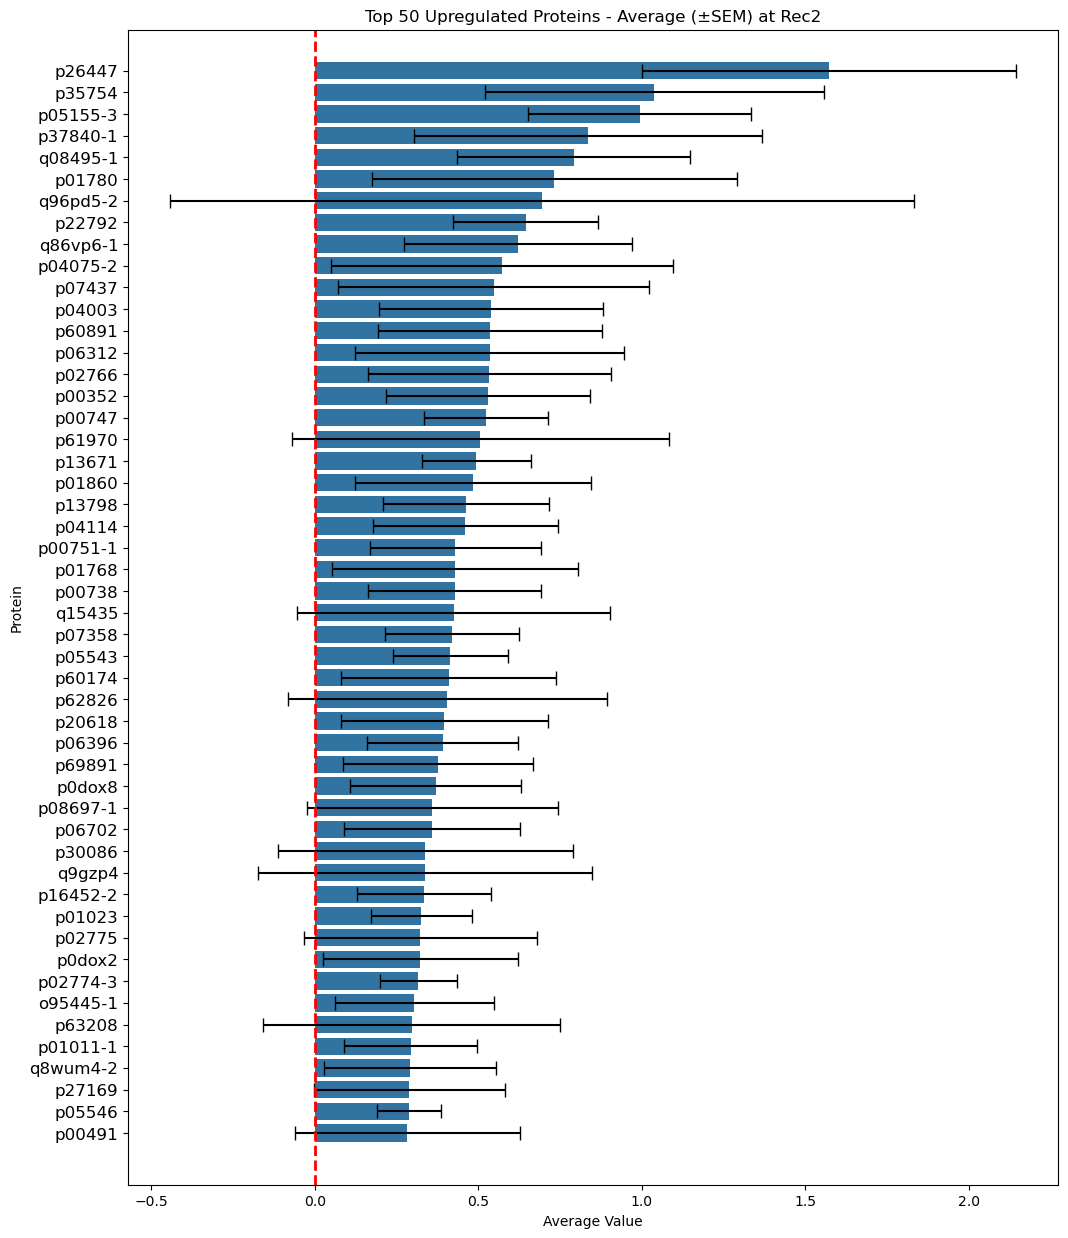

In [35]:
# identify unique timepoints
unique_timepoints = ['Rec2']

# Create a DataFrame to store average values and standard errors
# visuals_df = pd.DataFrame(columns=['Protein', 'Time', 'Average', 'SEM'])

## isolate relevant protein cols for this visual
df_Rec2_log2FC = df_Rec2_log2_fold_change.columns[2:]

## create empty list for calculated fold change mean + sem values for each protein 
new_rows = []
# Iterate over each protein column
for protein in df_Rec2_log2FC:
    # Iterate over each timepoint
    for timepoint in unique_timepoints:
        # Calculate the average and standard error for the current protein and timepoint
        subset = df_Rec2_log2_fold_change[df_Rec2_log2_fold_change['time']==timepoint]

        avg_val = subset[protein].mean()
        sem_val = subset[protein].sem()
        
        # Concatenate the result to the new_rows DataFrame to be concatenated with visuals_df
        new_rows.append({
            'Protein': protein,
            'Time': timepoint,
            'Average': avg_val,
            'SEM': sem_val
        })

        visuals_df = pd.DataFrame(new_rows)

# Select the 50 proteins with the **highest average values**
top_proteins = visuals_df.groupby('Protein')['Average'].mean().nlargest(50).index

# Filter the DataFrame for only those proteins and timepoints
filtered_df_top = visuals_df[
    (visuals_df['Protein'].isin(top_proteins)) &
    (visuals_df['Time'].isin(unique_timepoints))
].sort_values(by='Average', ascending=False)

# --- PLOTTING SECTION ---
for timepoint in unique_timepoints:
    plt.figure(figsize=(12, 15))

    # Barplot without built-in error bars
    ax = sns.barplot(
        x='Average', y='Protein',
        data=filtered_df_top[filtered_df_top['Time'] == timepoint],
        errorbar=None
    )

    # Add error bars manually
    for i, row in enumerate(filtered_df_top[filtered_df_top['Time'] == timepoint].itertuples()):
        plt.errorbar(x=row.Average, y=i, xerr=row.SEM, color='black', capsize=5)

    plt.title(f'Top 50 Upregulated Proteins - Average (±SEM) at {timepoint}')
    plt.xlabel('Average Value')
    plt.ylabel('Protein')

    # Visual formatting
    ax.set_ylim(bottom=ax.get_ylim()[0] - 0.5, top=ax.get_ylim()[1] + 1)
    ax.tick_params(axis='y', labelsize=12)
    plt.axvline(x=0, ls='--', color='red', lw=2)

    plt.show()

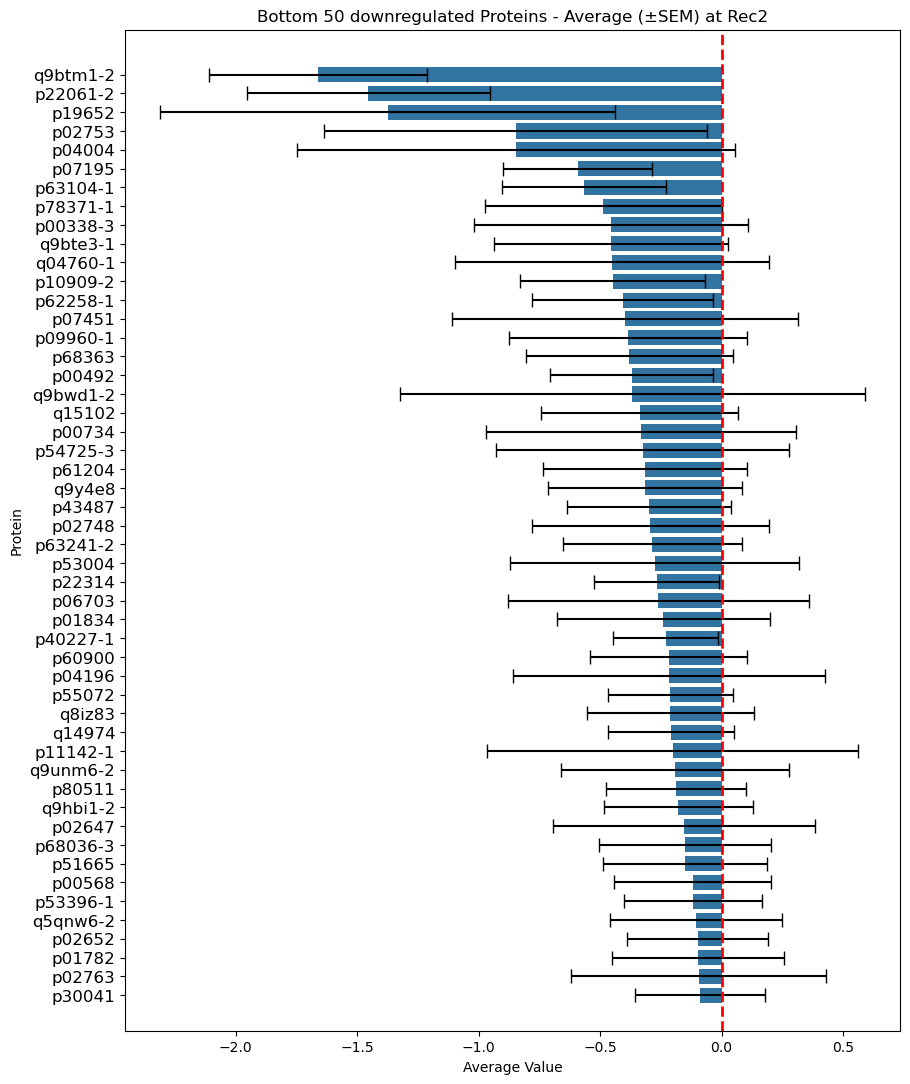

In [36]:
# identify unique timepoints
unique_timepoints = ['Rec2']

# Create a DataFrame to store average values and standard errors
# visuals_df = pd.DataFrame(columns=['Protein', 'Time', 'Average', 'SEM'])

## isolate relevant protein cols for this visual
df_Rec2_log2FC = df_Rec2_log2_fold_change.columns[2:]

## create empty list for calculated fold change mean + sem values for each protein 
new_rows = []
# Iterate over each protein column
for protein in df_Rec2_log2FC:
    # Iterate over each timepoint
    for timepoint in unique_timepoints:
        # Calculate the average and standard error for the current protein and timepoint
        subset = df_Rec2_log2_fold_change[df_Rec2_log2_fold_change['time']==timepoint]

        avg_val = subset[protein].mean()
        sem_val = subset[protein].sem()
        
        # Concatenate the result to the new_rows DataFrame to be concatenated with visuals_df
        new_rows.append({
            'Protein': protein,
            'Time': timepoint,
            'Average': avg_val,
            'SEM': sem_val
        })

        visuals_df = pd.DataFrame(new_rows)

# Select the 50 proteins with the **lowest average values**
bot_proteins = visuals_df.groupby('Protein')['Average'].mean().nsmallest(50).index

# Filter the DataFrame for only those proteins and timepoints
filtered_df_bot = visuals_df[
    (visuals_df['Protein'].isin(bot_proteins)) &
    (visuals_df['Time'].isin(unique_timepoints))
].sort_values(by='Average', ascending=False)

# --- PLOTTING SECTION ---
for timepoint in unique_timepoints:
    plt.figure(figsize=(10, 13))

    # Barplot without built-in error bars
    ax = sns.barplot(
        x='Average', y='Protein',
        data=filtered_df_bot[filtered_df_bot['Time'] == timepoint],
        errorbar=None
    )

    # Add error bars
    for i, row in enumerate(filtered_df_bot[filtered_df_bot['Time'] == timepoint].itertuples()):
        plt.errorbar(x=row.Average, y=i, xerr=row.SEM, color='black', capsize=5)

    plt.title(f'Bottom 50 downregulated Proteins - Average (±SEM) at {timepoint}')
    plt.xlabel('Average Value')
    plt.ylabel('Protein')

    ## Format
    ax.set_ylim(bottom=ax.get_ylim()[0] - 0.5, top=ax.get_ylim()[1] + 1)
    ax.tick_params(axis='y', labelsize=12)
    plt.axvline(x=0, ls='--', color='red', lw=2)
    ax.invert_yaxis()

    plt.show()

In [37]:
top_50_Rec2_PRO = filtered_df_top['Protein'].values

top_50_Rec2_PRO
#Here are the 50 proteins with the highest log2 fold change from Baseline to Rec2

array(['p26447', 'p35754', 'p05155-3', 'p37840-1', 'q08495-1', 'p01780',
       'q96pd5-2', 'p22792', 'q86vp6-1', 'p04075-2', 'p07437', 'p04003',
       'p60891', 'p06312', 'p02766', 'p00352', 'p00747', 'p61970',
       'p13671', 'p01860', 'p13798', 'p04114', 'p00751-1', 'p01768',
       'p00738', 'q15435', 'p07358', 'p05543', 'p60174', 'p62826',
       'p20618', 'p06396', 'p69891', 'p0dox8', 'p08697-1', 'p06702',
       'p30086', 'q9gzp4', 'p16452-2', 'p01023', 'p02775', 'p0dox2',
       'p02774-3', 'o95445-1', 'p63208', 'p01011-1', 'q8wum4-2', 'p27169',
       'p05546', 'p00491'], dtype=object)

In [38]:
bottom_50_Rec2_PRO=filtered_df_bot['Protein'].values

bottom_50_Rec2_PRO
#Here are the 50 proteins with the lowest, or most negative log 2fold change from Baseline to Rec2
## Can call these later into STRING.db or to examine as a subset of the data for statistical analysis.

array(['p30041', 'p02763', 'p01782', 'p02652', 'q5qnw6-2', 'p53396-1',
       'p00568', 'p51665', 'p68036-3', 'p02647', 'q9hbi1-2', 'p80511',
       'q9unm6-2', 'p11142-1', 'q14974', 'q8iz83', 'p55072', 'p04196',
       'p60900', 'p40227-1', 'p01834', 'p06703', 'p22314', 'p53004',
       'p63241-2', 'p02748', 'p43487', 'q9y4e8', 'p61204', 'p54725-3',
       'p00734', 'q15102', 'q9bwd1-2', 'p00492', 'p68363', 'p09960-1',
       'p07451', 'p62258-1', 'p10909-2', 'q04760-1', 'q9bte3-1',
       'p00338-3', 'p78371-1', 'p63104-1', 'p07195', 'p04004', 'p02753',
       'p19652', 'p22061-2', 'q9btm1-2'], dtype=object)

## Statistical Analyses of log2 fold change between BL and rec2 timepoints

**steps:**
- For each protein column, perform wilcoxon signed rank test (non-parametric dependent samples T-test) to determine significant changes in relative protein abundance from baseline (BL) to post-training (rec2) timepoints
- To adjust for Type I error rate, adjust p-values based on false discovery rate (FDR) using benjamini-hochberg method

**update:**
- Since this is a pilot investigation and there were no significant fold changes after p-value adjustment (all p-val adjusted > 0.05), focus on uncorrected p-values and set alpha-level significance to 0.1 instead of 0.05.
- These statistical analyses steps appropriate for exploratory (pilot) "omics" analyses and have been published in peer-reviewed literature.

In [39]:
import pandas as pd
from scipy.stats import wilcoxon

# Assuming you have a dataframe with protein abundance values (df_Log2_BL_Rec2_FC) and protein_cols defined

# Extract the relevant columns for the paired observations (e.g., 'BL' and 'Rec2' timepoints)
column_BL = 'BL'
column_Rec2 = 'Rec2'

# Create an empty list to store the results
wilcoxon_results = []

# Iterate over each protein column
for protein in df_Rec2_log2FC:
    # Select the data for the paired observations using loc
    data_BL = df_Log2_BL_Rec2_FC.loc[df_Log2_BL_Rec2_FC['time'] == column_BL, protein]
    data_Rec2 = df_Log2_BL_Rec2_FC.loc[df_Log2_BL_Rec2_FC['time'] == column_Rec2, protein]

    # Perform Wilcoxon signed-rank test
    statistic, p_value = wilcoxon(data_BL, data_Rec2)
    
    rounded_p_value = round(p_value, 3)

    # Append the results to the list
    wilcoxon_results.append({
        'Protein': protein,
        'Wilcoxon Statistic': statistic,
        'P-value': rounded_p_value
    })

# Create a DataFrame from the list of results
wilcoxon_df_BL_to_Rec2 = pd.concat([pd.DataFrame([result]) for result in wilcoxon_results], ignore_index=True)

In [40]:
print("Wilcoxon Signed-Rank Test Results:")
wilcoxon_df_BL_to_Rec2

Wilcoxon Signed-Rank Test Results:


,Protein,Wilcoxon Statistic,P-value
0,a0a0b4j1v0,13.0,0.938
1,a0a0c4dh25,7.0,0.297
2,o14818-1,12.0,0.812
3,o43681,11.0,0.688
4,o95445-1,7.0,0.297
...,...,...,...
204,p01008,13.0,0.938
205,p06396,6.0,0.219
206,p02753,12.0,0.812
207,Q06830,12.0,0.812


In [41]:
p_vals = wilcoxon_df_BL_to_Rec2['P-value'].values.tolist()

In [42]:
reject, corrected_pvals= smm.fdrcorrection(p_vals,
                 alpha=0.5,
                 is_sorted=False)

# Add the 'reject' and 'corrected_pvals' columns to the statistics DF
wilcoxon_df_BL_to_Rec2['reject'] = reject
wilcoxon_df_BL_to_Rec2['corrected_p_value'] = corrected_pvals

wilcoxon_df_BL_to_Rec2

,Protein,Wilcoxon Statistic,P-value,reject,corrected_p_value
0,a0a0b4j1v0,13.0,0.938,False,0.995137
1,a0a0c4dh25,7.0,0.297,False,0.969760
2,o14818-1,12.0,0.812,False,0.969760
3,o43681,11.0,0.688,False,0.969760
4,o95445-1,7.0,0.297,False,0.969760
...,...,...,...,...,...
204,p01008,13.0,0.938,False,0.995137
205,p06396,6.0,0.219,False,0.969760
206,p02753,12.0,0.812,False,0.969760
207,Q06830,12.0,0.812,False,0.969760


#BL to Rec21 Wilcoxon

In [43]:
protein_cols21= np.array(df_BL_Rec21.columns[2:])

len(protein_cols21) ## verifying the number of proteins identified in this dataset

219

In [44]:
## Isolate which proteins had a signficant log2 FC from BL to rec2 (P-val <=0.1)
bl_rec2_sig_pro = wilcoxon_df_BL_to_Rec2[wilcoxon_df_BL_to_Rec2['P-value']<=0.1].copy().reset_index(drop=True)

bl_rec2_sig_pro

,Protein,Wilcoxon Statistic,P-value,reject,corrected_p_value
0,p00747,0.0,0.016,False,0.96976
1,p01023,3.0,0.078,False,0.96976
2,p02730,3.0,0.078,False,0.96976
3,p02774-3,3.0,0.078,False,0.96976
4,p04632,2.0,0.094,False,0.96976
5,p05155-3,2.0,0.047,False,0.96976
6,p05543,3.0,0.078,False,0.96976
7,p05546,1.0,0.031,False,0.96976
8,p0c0l5,3.0,0.078,False,0.96976
9,p13671,2.0,0.047,False,0.96976


In [45]:
df_Rec2_log2_FC_prot = df_Rec2_log2_fold_change.columns[2:]

df_rec2_FC = df_Rec2_log2_fold_change[df_Rec2_log2_FC_prot].mean().reset_index().rename(columns={'index':'Protein', 0:'AVG_FC'
                                                                                                })
df_rec2_FC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Protein  209 non-null    object 
 1   AVG_FC   209 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.4+ KB


In [46]:
df_rec2_FC

,Protein,AVG_FC
0,a0a0b4j1v0,0.175381
1,a0a0c4dh25,0.262629
2,o14818-1,0.129526
3,o43681,0.132042
4,o95445-1,0.304682
...,...,...
204,p01008,0.013417
205,p06396,0.391633
206,p02753,-0.848018
207,Q06830,0.139335


In [47]:
## merge fold change average to each significant protein in a single DF

bl_rec2_sig_pro_FC = pd.merge(bl_rec2_sig_pro, df_rec2_FC[['Protein', 'AVG_FC']], how='inner', on='Protein')

### DF of proteins significantly altered from BL to rec2 including Wilcoxon signed-rank results and AVG_FC 
bl_rec2_sig_pro_FC

,Protein,Wilcoxon Statistic,P-value,reject,corrected_p_value,AVG_FC
0,p00747,0.0,0.016,False,0.96976,0.523186
1,p01023,3.0,0.078,False,0.96976,0.325703
2,p02730,3.0,0.078,False,0.96976,0.252418
3,p02774-3,3.0,0.078,False,0.96976,0.316248
4,p04632,2.0,0.094,False,0.96976,0.218820
5,p05155-3,2.0,0.047,False,0.96976,0.993958
6,p05543,3.0,0.078,False,0.96976,0.414385
7,p05546,1.0,0.031,False,0.96976,0.288005
8,p0c0l5,3.0,0.078,False,0.96976,0.198523
9,p13671,2.0,0.047,False,0.96976,0.494221


## Quick summary of results from BL to rec2 Log2 Fold Change:

- From baseline to rec2 timepoints, there were 209 out of 380 total proteins identified across all samples (n=7 subjects *2 timepoints)
- Log2 fold change was calculated and wilcoxon signed-rank tests were performed on each protein to determine which proteins were significantly up or downregulated from BL to rec2.
    - Alpha level was set to 0.1 given that this was an exploratory analysis/pilot investigation in line with published proteomics research.
    - Additionally, applying an adjustment for multiple comparisons (i.e., False Discovery Rate via Benjamini-Hochberg method) resulted in no significant changes in relative protein abundance.
- Significantly up or downregulated proteins (P <=0.1) were aggregated and will be entered as a list into STRING database to investigate shared biological processes) to drive future hypothesis testing.
- **Results:** **16 proteins were significantly up (n=14) or downregulated (n=2) from BL to rec2 timepoints.**

## Data visuals and statistical analysis of protein log2 fold change from baseline (BL) to post-recovery (rec21)

**steps:**
- Calculate log2 foldchange at baseline and rec21 timepoints
- Run Wilcoxon signed rank tests
    - look for p-adjusted <= 0.05, if not p-values (unadjusted) <=0.1 (exploratory data, pilot investigation)
- Identify list of proteins that have statistically significant log2 fold change from baseline
- Combine list of proteins with significant upregulation from BL to rec2 (post-training) or from 3-timepoint analysis (below)
- Input list of proteins into STRING database
- Build protein-protein interaction (PPI) networks of proteins with shared biological function (i.e., immune system function)

In [48]:
#Calculate Log2 Fold Change for Rec21 dataset
df_Rec21 = df_BL_Rec21[df_BL_Rec21['time']=='Rec21'].copy().reset_index(drop=True)
df_BL21 = df_BL_Rec21[df_BL_Rec21['time']=='BL'].copy().reset_index(drop=True)

#shape is good 7,221 for both

In [49]:
# # Calculate log2 fold change for df_BL_Rec21 (log2(A/A))
df_BL21_log2_fold_change = df_BL21.copy()
df_BL21_log2_fold_change[protein_cols21] = np.log2(df_BL21[protein_cols21]/ df_BL21[protein_cols21])

# # Calculate log2 fold change for df_Rec2 (log2(B/A))
df_Rec21_log2_fold_change = df_Rec21.copy()
df_Rec21_log2_fold_change[protein_cols21] = np.log2(df_Rec21[protein_cols21] / df_BL21[protein_cols21])

# math checks out

In [50]:
df_BL_Rec21_log2_fold_change= pd.concat([df_BL21_log2_fold_change,df_Rec21_log2_fold_change]).reset_index(drop=True)

df_BL_Rec21_log2_fold_change

,subject_id,time,a0a0b4j1v0,a0a0c4dh25,o14818-1,o43681,o95445-1,p00338-3,p00352,p00390,...,q9unm6-2,q9y3i1,q9y490,q9y570-4,p02768,p01008,p06396,p02753,Q06830,p62979
0,s10,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,s11,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,s18,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,s19,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,s23,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,s24,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,s25,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,s10,Rec21,0.047173,0.761110,-0.834392,0.048623,0.135101,1.619343,0.126704,0.758008,...,0.383889,0.283934,1.478654,0.295342,0.278269,0.899259,-0.172898,0.098253,-0.512962,0.851854
8,s11,Rec21,-0.789580,0.671119,-0.599270,0.449907,0.551434,2.794161,0.927344,0.615899,...,-0.083485,0.980752,3.505374,0.095325,0.667846,0.099315,0.710898,0.653383,-0.302855,1.203772
9,s18,Rec21,0.307916,1.004587,-0.385227,0.571077,-0.013788,-1.148425,-0.071168,0.374396,...,0.042554,0.440806,3.673211,-0.043502,0.317210,0.508324,1.227521,1.852158,-0.907606,-0.384748


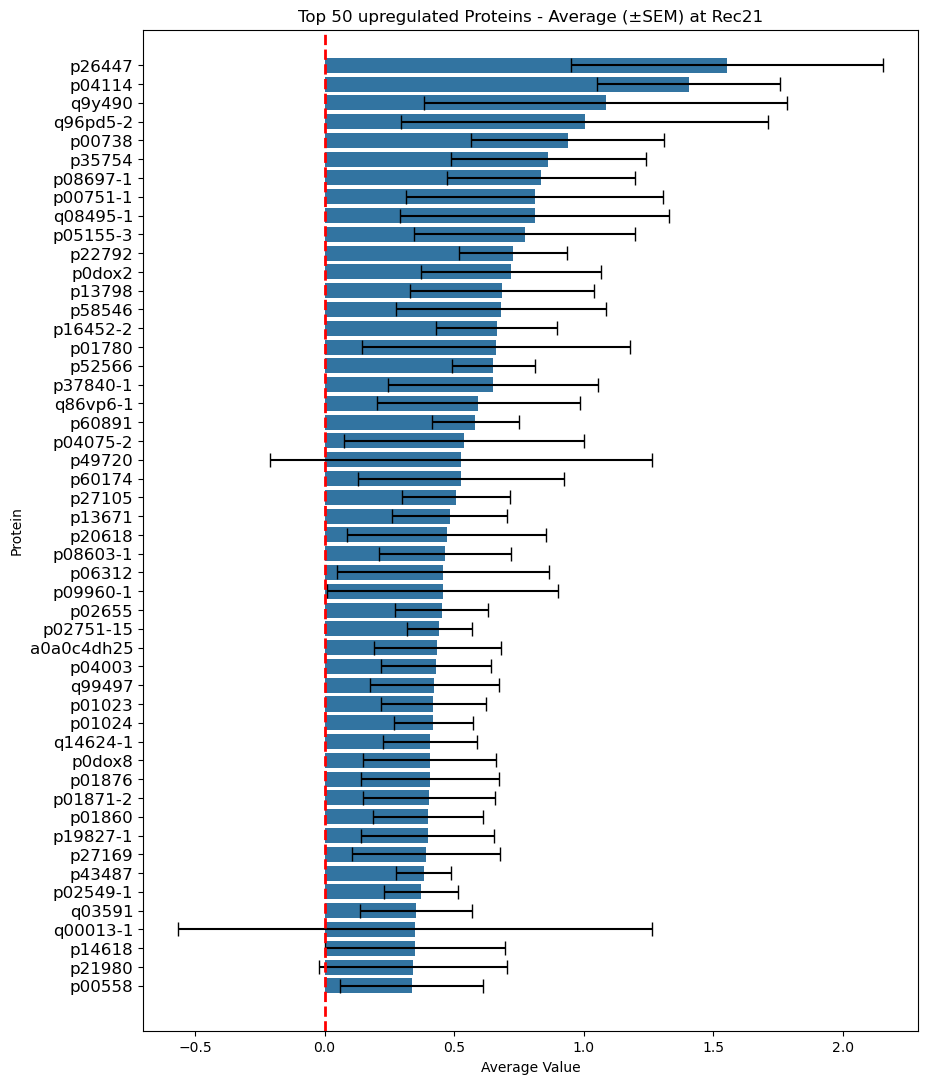

In [51]:
# Extract unique timepoints
unique_timepoints = ['Rec21']

## isolate protein cols in this sub dataset
df_BL_Rec21_prot = df_BL_Rec21_log2_fold_change.columns[2:]
## create emty list for calculated FC mean + sem values for each protein
new_rows21= []

# Iterate over each protein column
for protein in df_BL_Rec21_prot:
    # Iterate over each timepoint
    for timepoint in unique_timepoints:
        # Calculate the average and standard error for the current protein and timepoint
        subset = df_BL_Rec21_log2_fold_change[df_BL_Rec21_log2_fold_change['time']==timepoint]

        avg_val = subset[protein].mean()
        sem_val = subset[protein].sem()
        
        # Concatenate the result to the new_rows DataFrame to be concatenated with visuals_df
        new_rows21.append({
            'Protein': protein,
            'Time': timepoint,
            'Average': avg_val,
            'SEM': sem_val
        })

        visuals_df21 = pd.DataFrame(new_rows21)

# Select the 50 proteins with the **highest average values**
top_proteins = visuals_df21.groupby('Protein')['Average'].mean().nlargest(50).index

# Filter the DataFrame for only these proteins and timepoints
filtered_df_top21 = visuals_df21[
    (visuals_df21['Protein'].isin(top_proteins)) &
    (visuals_df21['Time'].isin(unique_timepoints))
].sort_values(by='Average', ascending=False)

## Plot 
for timepoint in unique_timepoints:
    plt.figure(figsize=(10, 13))

    # Barplot without built-in error bars
    ax = sns.barplot(
        x='Average', y='Protein',
        data=filtered_df_top21[filtered_df_top21['Time'] == timepoint],
        errorbar=None
    )

    # Add error bars
    for i, row in enumerate(filtered_df_top21[filtered_df_top21['Time'] == timepoint].itertuples()):
        plt.errorbar(x=row.Average, y=i, xerr=row.SEM, color='black', capsize=5)

    plt.title(f'Top 50 upregulated Proteins - Average (±SEM) at {timepoint}')
    plt.xlabel('Average Value')
    plt.ylabel('Protein')

    # Visual formatting
    ax.set_ylim(bottom=ax.get_ylim()[0] - 0.5, top=ax.get_ylim()[1] + 1)
    ax.tick_params(axis='y', labelsize=12)
    plt.axvline(x=0, ls='--', color='red', lw=2)


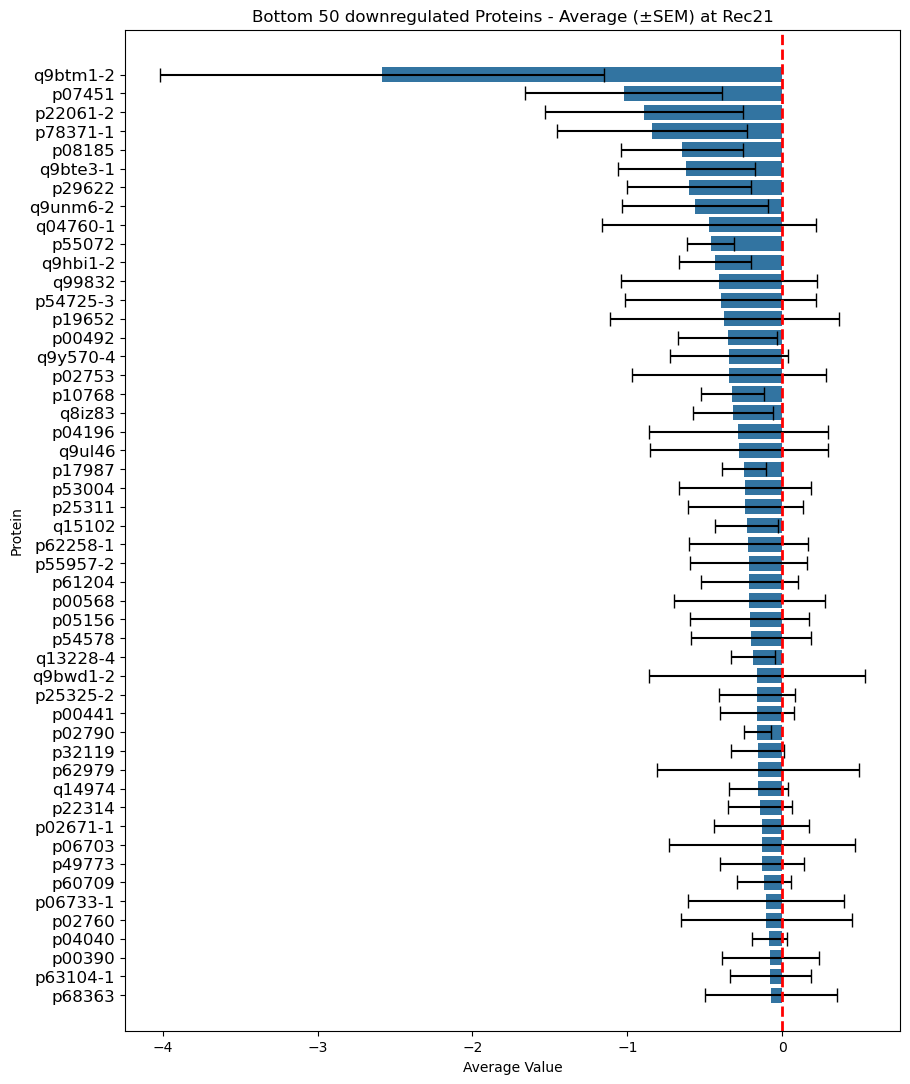

In [52]:
# Extract unique timepoints
unique_timepoints = ['Rec21']

## isolate protein cols in this sub dataset
df_BL_Rec21_prot = df_BL_Rec21_log2_fold_change.columns[2:]
## create emty list for calculated FC mean + sem values for each protein
new_rows21= []

# Iterate over each protein column
for protein in df_BL_Rec21_prot:
    # Iterate over each timepoint
    for timepoint in unique_timepoints:
        # Calculate the average and standard error for the current protein and timepoint
        subset = df_BL_Rec21_log2_fold_change[df_BL_Rec21_log2_fold_change['time']==timepoint]

        avg_val = subset[protein].mean()
        sem_val = subset[protein].sem()
        
        # Concatenate the result to the new_rows DataFrame to be concatenated with visuals_df
        new_rows21.append({
            'Protein': protein,
            'Time': timepoint,
            'Average': avg_val,
            'SEM': sem_val
        })

        visuals_df21 = pd.DataFrame(new_rows21)

# Select the 50 proteins with the **lowest average values**
lowest_proteins = visuals_df21.groupby('Protein')['Average'].mean().nsmallest(50).index

# Filter the DataFrame for only those proteins and timepoints
filtered_df_bot21 = visuals_df21[
    (visuals_df21['Protein'].isin(lowest_proteins)) &
    (visuals_df21['Time'].isin(unique_timepoints))
].sort_values(by='Average', ascending=False)

## Plot
for timepoint in unique_timepoints:
    plt.figure(figsize=(10, 13))

    # Barplot without built-in error bars
    ax = sns.barplot(
        x='Average', y='Protein',
        data=filtered_df_bot21[filtered_df_bot21['Time'] == timepoint],
        errorbar=None
    )

    # Add error bars
    for i, row in enumerate(filtered_df_bot21[filtered_df_bot21['Time'] == timepoint].itertuples()):
        plt.errorbar(x=row.Average, y=i, xerr=row.SEM, color='black', capsize=5)

    plt.title(f'Bottom 50 downregulated Proteins - Average (±SEM) at {timepoint}')
    plt.xlabel('Average Value')
    plt.ylabel('Protein')
    # Format
    ax.set_ylim(bottom=ax.get_ylim()[0] - 0.5, top=ax.get_ylim()[1] + 1)
    ax.tick_params(axis='y', labelsize=12)
    plt.axvline(x=0, ls='--', color='red', lw=2)

    ## invert axis to visualize proteins from largest to smallest magnitude of FC
    ax.invert_yaxis()

    plt.show()


In [53]:
filtered_df_top21['Protein'].values

array(['p26447', 'p04114', 'q9y490', 'q96pd5-2', 'p00738', 'p35754',
       'p08697-1', 'p00751-1', 'q08495-1', 'p05155-3', 'p22792', 'p0dox2',
       'p13798', 'p58546', 'p16452-2', 'p01780', 'p52566', 'p37840-1',
       'q86vp6-1', 'p60891', 'p04075-2', 'p49720', 'p60174', 'p27105',
       'p13671', 'p20618', 'p08603-1', 'p06312', 'p09960-1', 'p02655',
       'p02751-15', 'a0a0c4dh25', 'p04003', 'q99497', 'p01023', 'p01024',
       'q14624-1', 'p0dox8', 'p01876', 'p01871-2', 'p01860', 'p19827-1',
       'p27169', 'p43487', 'p02549-1', 'q03591', 'q00013-1', 'p14618',
       'p21980', 'p00558'], dtype=object)

In [54]:
filtered_df_bot21['Protein'].values

array(['p68363', 'p63104-1', 'p00390', 'p04040', 'p02760', 'p06733-1',
       'p60709', 'p49773', 'p06703', 'p02671-1', 'p22314', 'q14974',
       'p62979', 'p32119', 'p02790', 'p00441', 'p25325-2', 'q9bwd1-2',
       'q13228-4', 'p54578', 'p05156', 'p00568', 'p61204', 'p55957-2',
       'p62258-1', 'q15102', 'p25311', 'p53004', 'p17987', 'q9ul46',
       'p04196', 'q8iz83', 'p10768', 'p02753', 'q9y570-4', 'p00492',
       'p19652', 'p54725-3', 'q99832', 'q9hbi1-2', 'p55072', 'q04760-1',
       'q9unm6-2', 'p29622', 'q9bte3-1', 'p08185', 'p78371-1', 'p22061-2',
       'p07451', 'q9btm1-2'], dtype=object)

## Statistical analyses of log2 FC from BL (baseline) to rec21 (post-recovery; END) timepoints

**steps:**
- For each protein column, perform wilcoxon signed rank test (non-parametric dependent samples T-test) to determine significant changes in relative protein abundance from baseline (BL) to post-recovery (rec21) timepoints
- To adjust for Type I error rate, adjust p-values based on false discovery rate (FDR) using benjamini-hochberg method

**update:**
- Since this is a pilot investigation and there were no significant fold changes after p-value adjustment (all p-val adjusted > 0.05), focus on uncorrected p-values and set alpha-level significance to 0.1 instead of 0.05.
- These statistical analyses steps appropriate for exploratory (pilot) "omics" analyses and have been published in peer-reviewed literature.

In [55]:
column_BL = 'BL'
column_Rec21 = 'Rec21'

# Create an empty list to store the results
wilcoxon_results = []

# Iterate over each protein column
for protein in protein_cols21:
    # Select the data for the paired observations using loc
    data_BL = df_BL_Rec21_log2_fold_change.loc[df_BL_Rec21_log2_fold_change['time'] == column_BL, protein]
    data_Rec21 = df_BL_Rec21_log2_fold_change.loc[df_BL_Rec21_log2_fold_change['time'] == column_Rec21, protein]

    # Perform Wilcoxon signed-rank test
    statistic, p_value = wilcoxon(data_BL, data_Rec21)
    
    rounded_p_value = round(p_value, 3)

    # Append the results to the list
    wilcoxon_results.append({
        'Protein': protein,
        'Wilcoxon Statistic': statistic,
        'P-value': rounded_p_value
    })

# Create a DataFrame from the list of results
wilcoxon_df_BL_to_Rec21 = pd.concat([pd.DataFrame([result]) for result in wilcoxon_results], ignore_index=True)


In [56]:
print("Wilcoxon Signed-Rank Test Results:")
wilcoxon_df_BL_to_Rec21

Wilcoxon Signed-Rank Test Results:


,Protein,Wilcoxon Statistic,P-value
0,a0a0b4j1v0,6.0,0.219
1,a0a0c4dh25,4.0,0.109
2,o14818-1,9.0,0.469
3,o43681,8.0,0.375
4,o95445-1,7.0,0.297
...,...,...,...
214,p01008,12.0,0.812
215,p06396,13.0,0.938
216,p02753,12.0,0.812
217,Q06830,14.0,1.000


In [57]:
p_vals21=wilcoxon_df_BL_to_Rec21['P-value'].values.tolist()

In [58]:
reject, corrected_pvals21= smm.fdrcorrection(p_vals21,
                 alpha=0.5,
                 is_sorted=False)

# Add the 'reject' and 'corrected_pvals' columns to your DataFrame
wilcoxon_df_BL_to_Rec21['reject'] = reject
wilcoxon_df_BL_to_Rec21['corrected_p_value'] = corrected_pvals21

wilcoxon_df_BL_to_Rec21.sort_values('corrected_p_value', ascending=True)

,Protein,Wilcoxon Statistic,P-value,reject,corrected_p_value
113,p22792,1.0,0.031,False,0.617182
119,p27105,1.0,0.031,False,0.617182
59,p04114,0.0,0.016,False,0.617182
48,p02751-15,1.0,0.031,False,0.617182
103,p16452-2,1.0,0.031,False,0.617182
...,...,...,...,...,...
174,p68363,14.0,1.000,False,1.000000
30,p01834,14.0,1.000,False,1.000000
161,p60842,14.0,1.000,False,1.000000
131,p31946,14.0,1.000,False,1.000000


In [59]:
bl_rec21_sig_pro = wilcoxon_df_BL_to_Rec21[wilcoxon_df_BL_to_Rec21['P-value']<=0.1].reset_index(drop=True)

bl_rec21_sig_pro

,Protein,Wilcoxon Statistic,P-value,reject,corrected_p_value
0,p00738,1.0,0.031,False,0.617182
1,p00747,0.0,0.016,False,0.617182
2,p01024,3.0,0.078,False,0.749391
3,p02549-1,3.0,0.078,False,0.749391
4,p02751-15,1.0,0.031,False,0.617182
5,p04114,0.0,0.016,False,0.617182
6,p07451,3.0,0.078,False,0.749391
7,p08697-1,3.0,0.078,False,0.749391
8,p13798,3.0,0.078,False,0.749391
9,p16452-2,1.0,0.031,False,0.617182


In [60]:
# df_BL_Rec21_prot = df_BL_Rec21_log2_fold_change.columns[2:]
df_BL_Rec21_log2_FC = df_BL_Rec21_log2_fold_change[df_BL_Rec21_prot].mean().reset_index().rename(columns={'index':'Protein', 0:'AVG_FC'})

bl_rec21_sig_pro_FC = pd.merge(bl_rec21_sig_pro, df_BL_Rec21_log2_FC[['Protein', 'AVG_FC']], how='inner', on='Protein')

### Significantly up/downregulated proteins from BL to rec21 with average FC
bl_rec21_sig_pro_FC

,Protein,Wilcoxon Statistic,P-value,reject,corrected_p_value,AVG_FC
0,p00738,1.0,0.031,False,0.617182,0.468732
1,p00747,0.0,0.016,False,0.617182,0.146412
2,p01024,3.0,0.078,False,0.749391,0.209341
3,p02549-1,3.0,0.078,False,0.749391,0.186795
4,p02751-15,1.0,0.031,False,0.617182,0.220977
5,p04114,0.0,0.016,False,0.617182,0.702642
6,p07451,3.0,0.078,False,0.749391,-0.511396
7,p08697-1,3.0,0.078,False,0.749391,0.417502
8,p13798,3.0,0.078,False,0.749391,0.342568
9,p16452-2,1.0,0.031,False,0.617182,0.331865


## Quick summary of results from BL to rec21 Log2 Fold Change:

- From baseline to rec21 timepoints, there were 219 out of 380 total proteins identified across all samples (n=7 subjects *2 timepoints)
- Log2 fold change was calculated and wilcoxon signed-rank tests were performed on each protein to determine which proteins were significantly up or downregulated from BL to rec2.
    - Alpha level was set to 0.1 given that this was an exploratory analysis/pilot investigation in line with published proteomics research.
    - Additionally, applying an adjustment for multiple comparisons (i.e., False Discovery Rate via Benjamini-Hochberg method) resulted in no significant changes in relative protein abundance.
- Significantly up or downregulated proteins (P <=0.1) were aggregated and will be entered as a list into STRING database to investigate shared biological processes) to drive future hypothesis testing.
- **Results:** **19 proteins were significantly up (n=17) or downregulated (n=2) from BL to rec21 timepoints.**

In [61]:
protein_names_df = pd.read_excel('/Users/thomasgooding/Desktop/2025 proteomics data/Gooding Proteomics 10.30.23 (original dataset).xlsx', usecols=['Accession', 'Description'])
protein_names_df['Accession'] = protein_names_df['Accession'].str.lower()

protein_names_df.head()

,Accession,Description
0,p02768,Serum albumin [OS=Homo sapiens]
1,p01023,alpha-2-macroglobulin [OS=Homo sapiens]
2,p01024,Complement C3 [OS=Homo sapiens]
3,p02549-1,"spectrin alpha chain, erythrocytic 1 [OS=Homo ..."
4,p11277-2,"Isoform 2 of Spectrin beta chain, erythrocytic..."


In [62]:
protein_names_check = ['q06830', 'a0a0a0mrq5']

protein_names_df[protein_names_df['Accession'].isin(protein_names_check)]



,Accession,Description
115,q06830,peroxiredoxin-1 [OS=Homo sapiens]


In [63]:
### Adding protien descriptions to each final results_df
bl_rec2_sig_pro_FC_final = pd.merge(bl_rec2_sig_pro_FC,protein_names_df[['Accession','Description']], left_on='Protein', right_on='Accession', how='inner' )

# bl_rec2_sig_pro_FC_final

bl_rec2_sig_pro_FC_final.to_excel('bl_rec2_sig_pro_FC_final 10.15.25.xlsx')

In [64]:
### Adding protien descriptions to each final results_df
bl_rec21_sig_pro_FC_final = pd.merge(bl_rec21_sig_pro_FC,protein_names_df[['Accession','Description']], left_on='Protein', right_on='Accession', how='inner' )

# bl_rec21_sig_pro_FC_final
bl_rec21_sig_pro_FC_final.to_excel('bl_rec21_sig_pro_FC_final 10.15.25.xlsx')

In [65]:
### alternatively, add both sets of data into single DF prior to export

In [66]:
bl_rec2_sig_pro_FC_final['time'] = 'MID'

bl_rec2_sig_pro_FC_final.head()

,Protein,Wilcoxon Statistic,P-value,reject,corrected_p_value,AVG_FC,Accession,Description,time
0,p00747,0.0,0.016,False,0.96976,0.523186,p00747,Plasminogen [OS=Homo sapiens],MID
1,p01023,3.0,0.078,False,0.96976,0.325703,p01023,alpha-2-macroglobulin [OS=Homo sapiens],MID
2,p02730,3.0,0.078,False,0.96976,0.252418,p02730,Band 3 anion transport protein [OS=Homo sapiens],MID
3,p02774-3,3.0,0.078,False,0.96976,0.316248,p02774-3,Isoform 3 of Vitamin D-binding protein [OS=Hom...,MID
4,p04632,2.0,0.094,False,0.96976,0.218820,p04632,Calpain small subunit 1 [OS=Homo sapiens],MID


In [67]:
bl_rec21_sig_pro_FC_final['time'] = 'END'

bl_rec21_sig_pro_FC_final.head()

,Protein,Wilcoxon Statistic,P-value,reject,corrected_p_value,AVG_FC,Accession,Description,time
0,p00738,1.0,0.031,False,0.617182,0.468732,p00738,Haptoglobin [OS=Homo sapiens],END
1,p00747,0.0,0.016,False,0.617182,0.146412,p00747,Plasminogen [OS=Homo sapiens],END
2,p01024,3.0,0.078,False,0.749391,0.209341,p01024,Complement C3 [OS=Homo sapiens],END
3,p02549-1,3.0,0.078,False,0.749391,0.186795,p02549-1,"spectrin alpha chain, erythrocytic 1 [OS=Homo ...",END
4,p02751-15,1.0,0.031,False,0.617182,0.220977,p02751-15,Isoform 15 of Fibronectin [OS=Homo sapiens],END


In [68]:
all_FC_df = pd.concat([bl_rec2_sig_pro_FC_final,bl_rec21_sig_pro_FC_final], ignore_index=True)

all_FC_df

,Protein,Wilcoxon Statistic,P-value,reject,corrected_p_value,AVG_FC,Accession,Description,time
0,p00747,0.0,0.016,False,0.969760,0.523186,p00747,Plasminogen [OS=Homo sapiens],MID
1,p01023,3.0,0.078,False,0.969760,0.325703,p01023,alpha-2-macroglobulin [OS=Homo sapiens],MID
2,p02730,3.0,0.078,False,0.969760,0.252418,p02730,Band 3 anion transport protein [OS=Homo sapiens],MID
3,p02774-3,3.0,0.078,False,0.969760,0.316248,p02774-3,Isoform 3 of Vitamin D-binding protein [OS=Hom...,MID
4,p04632,2.0,0.094,False,0.969760,0.218820,p04632,Calpain small subunit 1 [OS=Homo sapiens],MID
5,p05155-3,2.0,0.047,False,0.969760,0.993958,p05155-3,Isoform 3 of Plasma protease C1 inhibitor [OS=...,MID
6,p05543,3.0,0.078,False,0.969760,0.414385,p05543,thyroxine-binding globulin [OS=Homo sapiens],MID
7,p05546,1.0,0.031,False,0.969760,0.288005,p05546,Heparin cofactor 2 [OS=Homo sapiens],MID
8,p0c0l5,3.0,0.078,False,0.969760,0.198523,p0c0l5,Complement C4-B [OS=Homo sapiens],MID
9,p13671,2.0,0.047,False,0.969760,0.494221,p13671,Complement component c6 [OS=Homo sapiens],MID


# Kruskal-Wallis 1x3 (non-parametric ANOVA) between the three timepoints

In [69]:
### isolate proteins that show up at all 3 timepoints in 100% of samples (21 samples, n=7 participants, 3 timepoints each)

protein_cols_3tp = np.array(df_three_visits.columns[2:])

len(protein_cols_3tp)

## 206 proteins present in all samples

206

In [70]:
df_BL_3tp= df_three_visits[df_three_visits['time']=='BL'].copy().reset_index(drop=True)

df_Rec2_3tp= df_three_visits[df_three_visits['time']=='Rec2'].copy().reset_index(drop=True)

df_Rec21_3tp= df_three_visits[df_three_visits['time']=='Rec21'].copy().reset_index(drop=True)

df_Rec2_3tp

,subject_id,time,a0a0b4j1v0,a0a0c4dh25,o14818-1,o43681,o95445-1,p00338-3,p00352,p00390,...,q9hbi1-2,q9ul46,q9unm6-2,q9y3i1,p02768,p01008,p06396,p02753,Q06830,p62979
0,s10,Rec2,79.5,72.1,57.2,71.7,121.7,84.9,96.0,131.0,...,66.2,156.0,144.0,124.4,102.4,117.4,77.5,73.6,103.3,175.9
1,s11,Rec2,77.9,68.4,76.7,47.9,73.8,47.4,80.0,79.5,...,111.6,104.5,86.7,95.7,95.2,142.2,83.7,91.5,70.9,257.9
2,s18,Rec2,98.5,83.6,52.4,83.2,120.0,47.2,100.3,123.4,...,110.9,88.7,43.7,125.5,96.7,48.5,78.2,55.7,82.8,88.0
3,s19,Rec2,62.2,80.9,27.2,65.2,99.6,71.5,108.3,93.8,...,78.2,58.7,70.6,75.9,81.4,66.4,231.2,80.2,76.3,44.0
4,s23,Rec2,132.4,71.7,31.7,68.0,66.9,77.5,48.1,72.6,...,85.2,55.8,100.9,124.2,95.1,105.2,68.5,50.0,75.7,44.9
5,s24,Rec2,51.2,109.8,121.3,115.0,169.7,40.6,92.1,190.4,...,95.5,83.2,213.4,113.6,139.4,180.1,164.4,115.8,38.5,260.1
6,s25,Rec2,235.8,238.2,548.2,223.3,93.0,41.5,322.3,28.7,...,110.3,76.3,61.8,68.8,112.1,56.3,143.0,3.1,367.1,8.5


In [71]:
df_BL_3tp_log2_fold_change = df_BL_3tp.copy()
df_BL_3tp_log2_fold_change[protein_cols_3tp] = np.log2(df_BL_3tp[protein_cols_3tp]/ df_BL_3tp[protein_cols_3tp])

# Calculate log2 fold change for df_Rec2 (log2(B/A))
df_Rec2_3tp_log2_fold_change = df_Rec2_3tp.copy()
df_Rec2_3tp_log2_fold_change[protein_cols_3tp] = np.log2(df_Rec2_3tp[protein_cols_3tp] / df_BL_3tp[protein_cols_3tp])

# Calculate log2 fold change for df_Rec21 (log2(C/A))
df_Rec21_3tp_log2_fold_change = df_Rec21_3tp.copy()
df_Rec21_3tp_log2_fold_change[protein_cols_3tp] = np.log2(df_Rec21_3tp[protein_cols_3tp] / df_BL_3tp[protein_cols_3tp])


In [72]:
df_3tp_log2_fold_change= pd.concat([df_BL_3tp_log2_fold_change,
                                    df_Rec2_3tp_log2_fold_change,
                                    df_Rec21_3tp_log2_fold_change],
                                  ).reset_index(drop=True)

df_3tp_log2_fold_change

#log2 fold change df looks good

,subject_id,time,a0a0b4j1v0,a0a0c4dh25,o14818-1,o43681,o95445-1,p00338-3,p00352,p00390,...,q9hbi1-2,q9ul46,q9unm6-2,q9y3i1,p02768,p01008,p06396,p02753,Q06830,p62979
0,s10,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,s11,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,s18,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,s19,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,s23,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,s24,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,s25,BL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,s10,Rec2,-0.405479,0.372322,-0.449307,0.095660,1.017892,1.133431,0.906891,0.973808,...,-1.477153,1.026130,0.483424,0.767043,0.383451,1.078276,-0.133267,0.487388,-0.570458,2.083572
8,s11,Rec2,-0.635312,0.395485,-0.249807,-0.639150,0.053771,1.216318,0.365407,-0.517474,...,-0.794742,0.660781,-0.522042,0.205408,0.323065,0.123872,0.077907,0.188372,-0.891205,2.211063
9,s18,Rec2,0.287555,-0.172224,-0.821445,0.257496,-0.394148,-1.601173,-0.264712,-0.240648,...,-0.741382,-0.323554,-1.499974,-0.370976,-0.019266,-1.069681,0.197397,-1.553541,0.131245,-1.111183


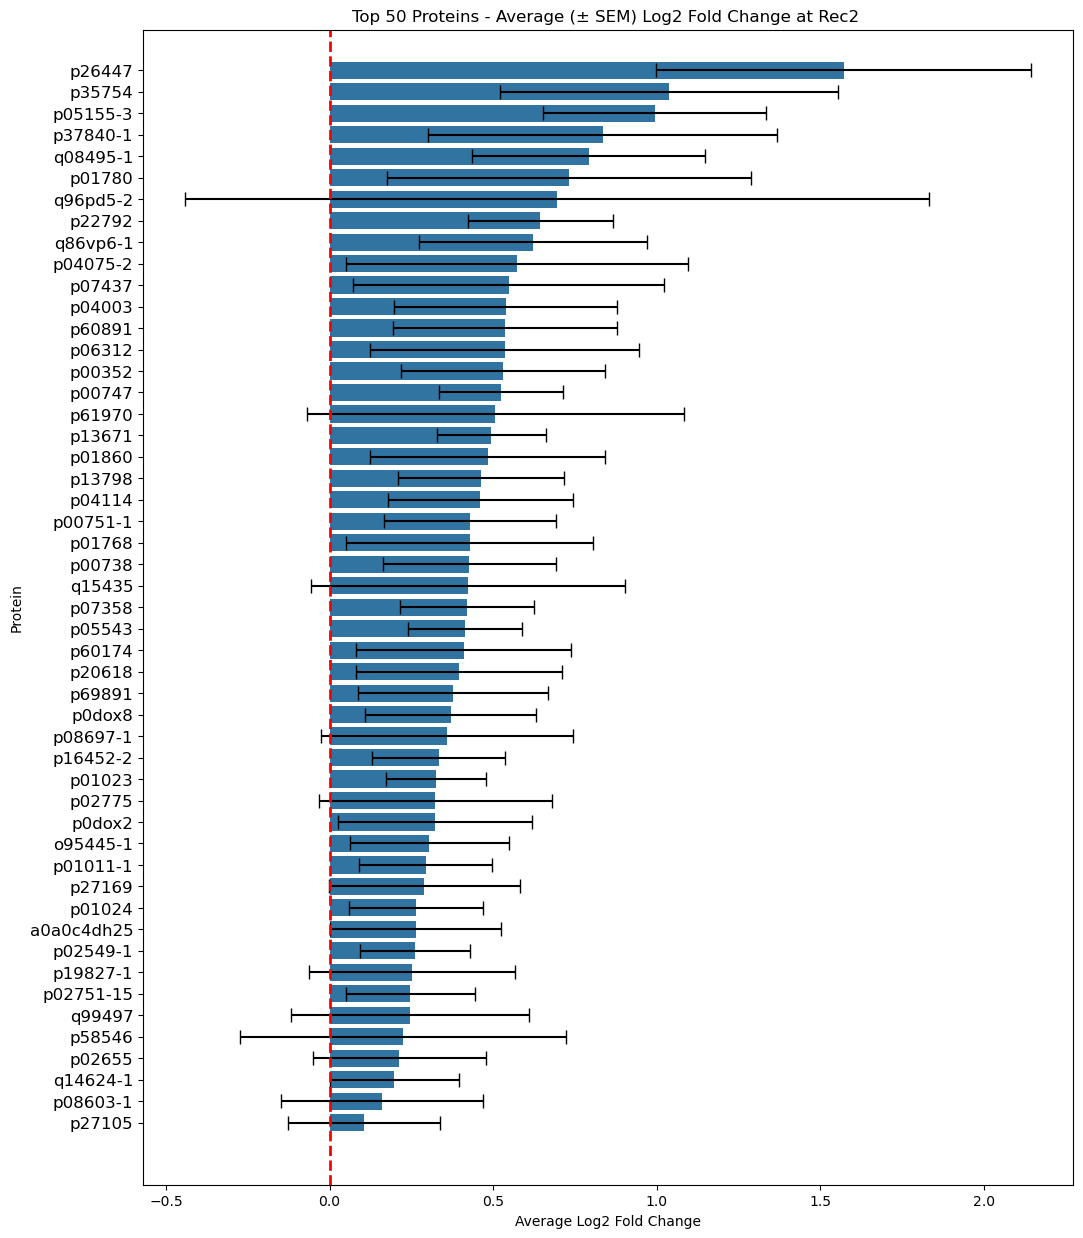

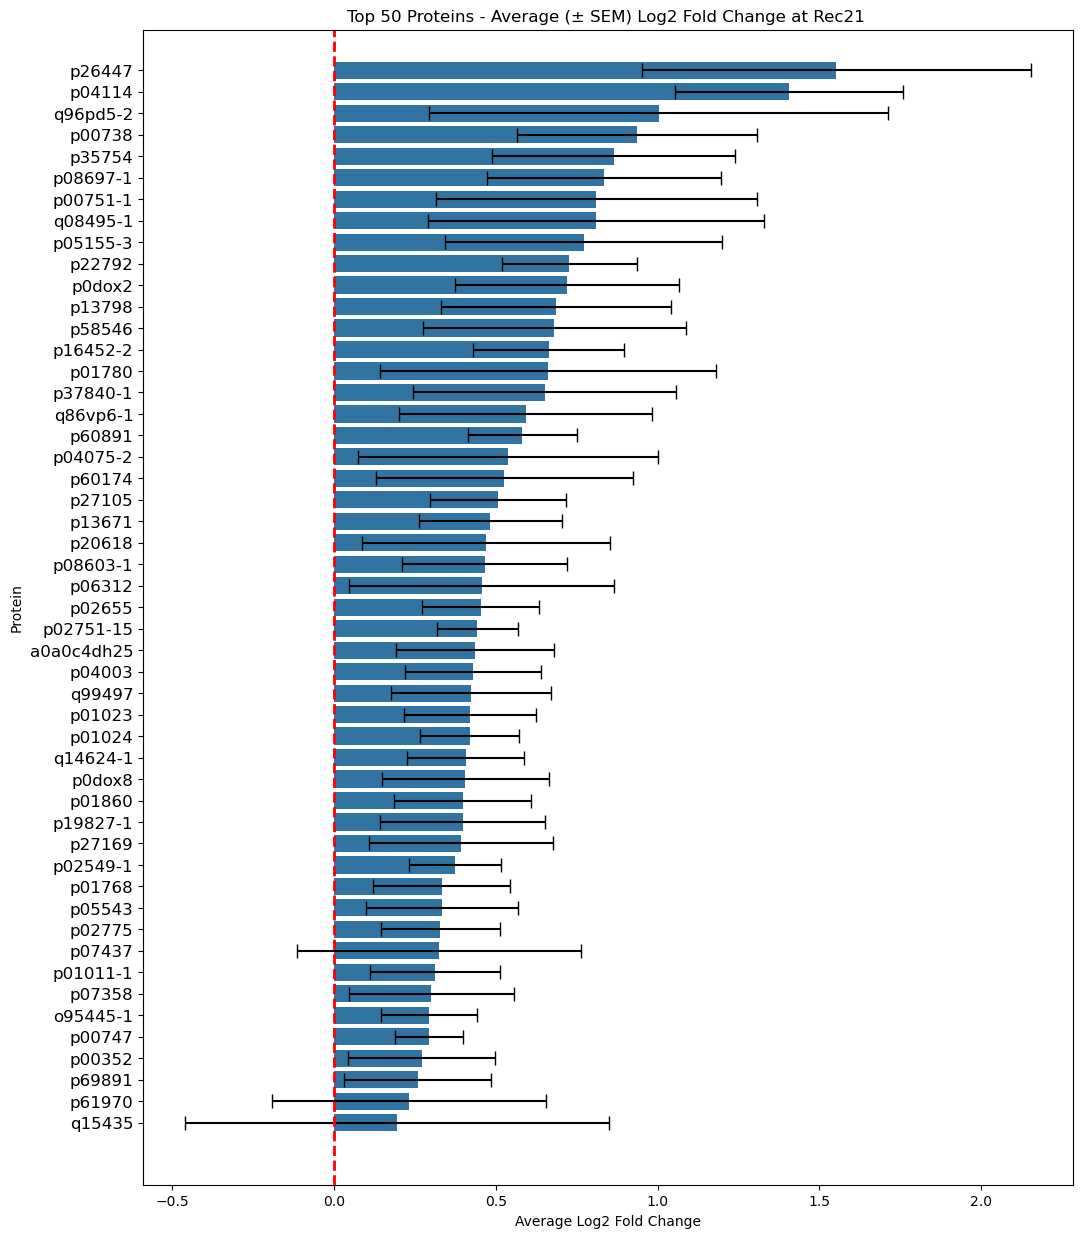

In [73]:
# Extract unique timepoints
unique_timepoints = ['Rec2', 'Rec21']

## new df to hold average + sem fold change values

new_rows_3tp = []
# Create a DataFrame to store average values and standard errors
average_df = pd.DataFrame(columns=['Protein', 'Time', 'Average', 'Std_Error'])

# Iterate over each protein column
for protein in protein_cols_3tp:
    # Iterate over each timepoint
    for timepoint in unique_timepoints:
        # Calculate the average and standard error for the current protein and timepoint
        subset = df_3tp_log2_fold_change[df_3tp_log2_fold_change['time'] == timepoint]

        avg_val = subset[protein].mean()
        sem_val = subset[protein].sem()

        new_rows_3tp.append({
            'Protein': protein,
            'Time': timepoint,
            'Average': avg_val,
            'SEM': sem_val
        })
        visuals_df_3tp = pd.DataFrame(new_rows_3tp)

# visuals_df_3tp
# Select the top 50 proteins based on the highest average log2 fold change
top_proteins = visuals_df_3tp.groupby('Protein')['Average'].mean().nlargest(50).index

# Filter the DataFrame to include only the top 50 proteins and the specified timepoints
filtered_df = visuals_df_3tp[(visuals_df_3tp['Protein'].isin(top_proteins)) & (visuals_df_3tp['Time'].isin(unique_timepoints))]

# Sort the DataFrame by 'Average' column in descending order
filtered_df = filtered_df.sort_values(by='Average', ascending=False)

# Create separate bar plots for each timepoint
for timepoint in unique_timepoints:
    plt.figure(figsize=(12, 15))
    
    # Create the first y-axis with error bars
    ax = sns.barplot(x='Average', y='Protein', data=filtered_df[filtered_df['Time'] == timepoint],
                     dodge=1.5, errorbar=None)
    
    # Add error bars manually using the Std_Error column with caps
    for i, value in enumerate(filtered_df[filtered_df['Time'] == timepoint]['Average']):
        plt.errorbar(x=value, y=i, xerr=filtered_df[filtered_df['Time'] == timepoint]['SEM'].iloc[i],
                     color='black', capsize=5)  # Set capsize to adjust the length of caps
    
    plt.title(f'Top 50 Proteins - Average (± SEM) Log2 Fold Change at {timepoint} ')
    plt.xlabel('Average Log2 Fold Change')
    plt.ylabel('Protein')
    
    # Adjust y-axis ticks
    ax.set_ylim(bottom=ax.get_ylim()[0], top=ax.get_ylim()[1] + 1)
    ax.tick_params(axis='y', labelsize=12)
    plt.axvline(x=0, ls='--', color='red', lw=2)    
    plt.show()


In [74]:
visuals_df_3tp[visuals_df_3tp['Average']<=0]

,Protein,Time,Average,SEM
10,p00338-3,Rec2,-0.454866,0.565345
14,p00390,Rec2,-0.012917,0.382896
15,p00390,Rec21,-0.075810,0.312181
17,p00441,Rec21,-0.161864,0.236682
22,p00492,Rec2,-0.370223,0.335097
...,...,...,...,...
397,q9unm6-2,Rec21,-0.562100,0.473420
405,p06396,Rec21,-0.044515,0.412852
406,p02753,Rec2,-0.848018,0.789619
407,p02753,Rec21,-0.342440,0.624621


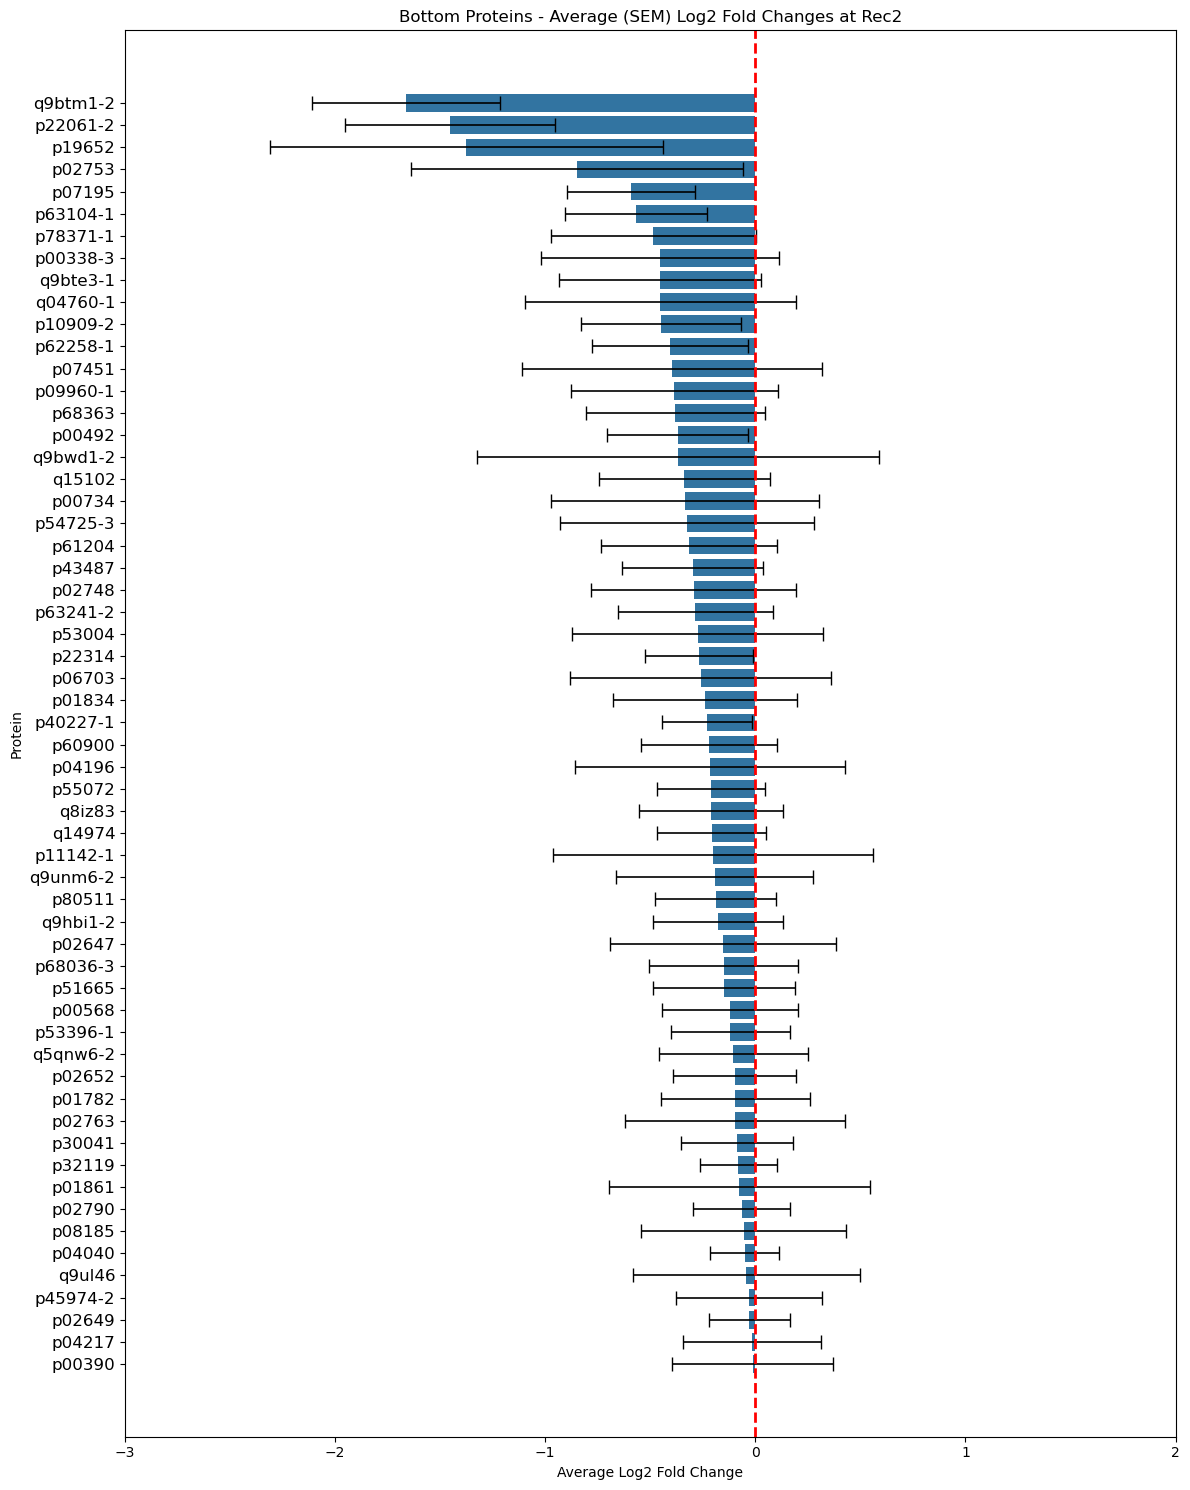

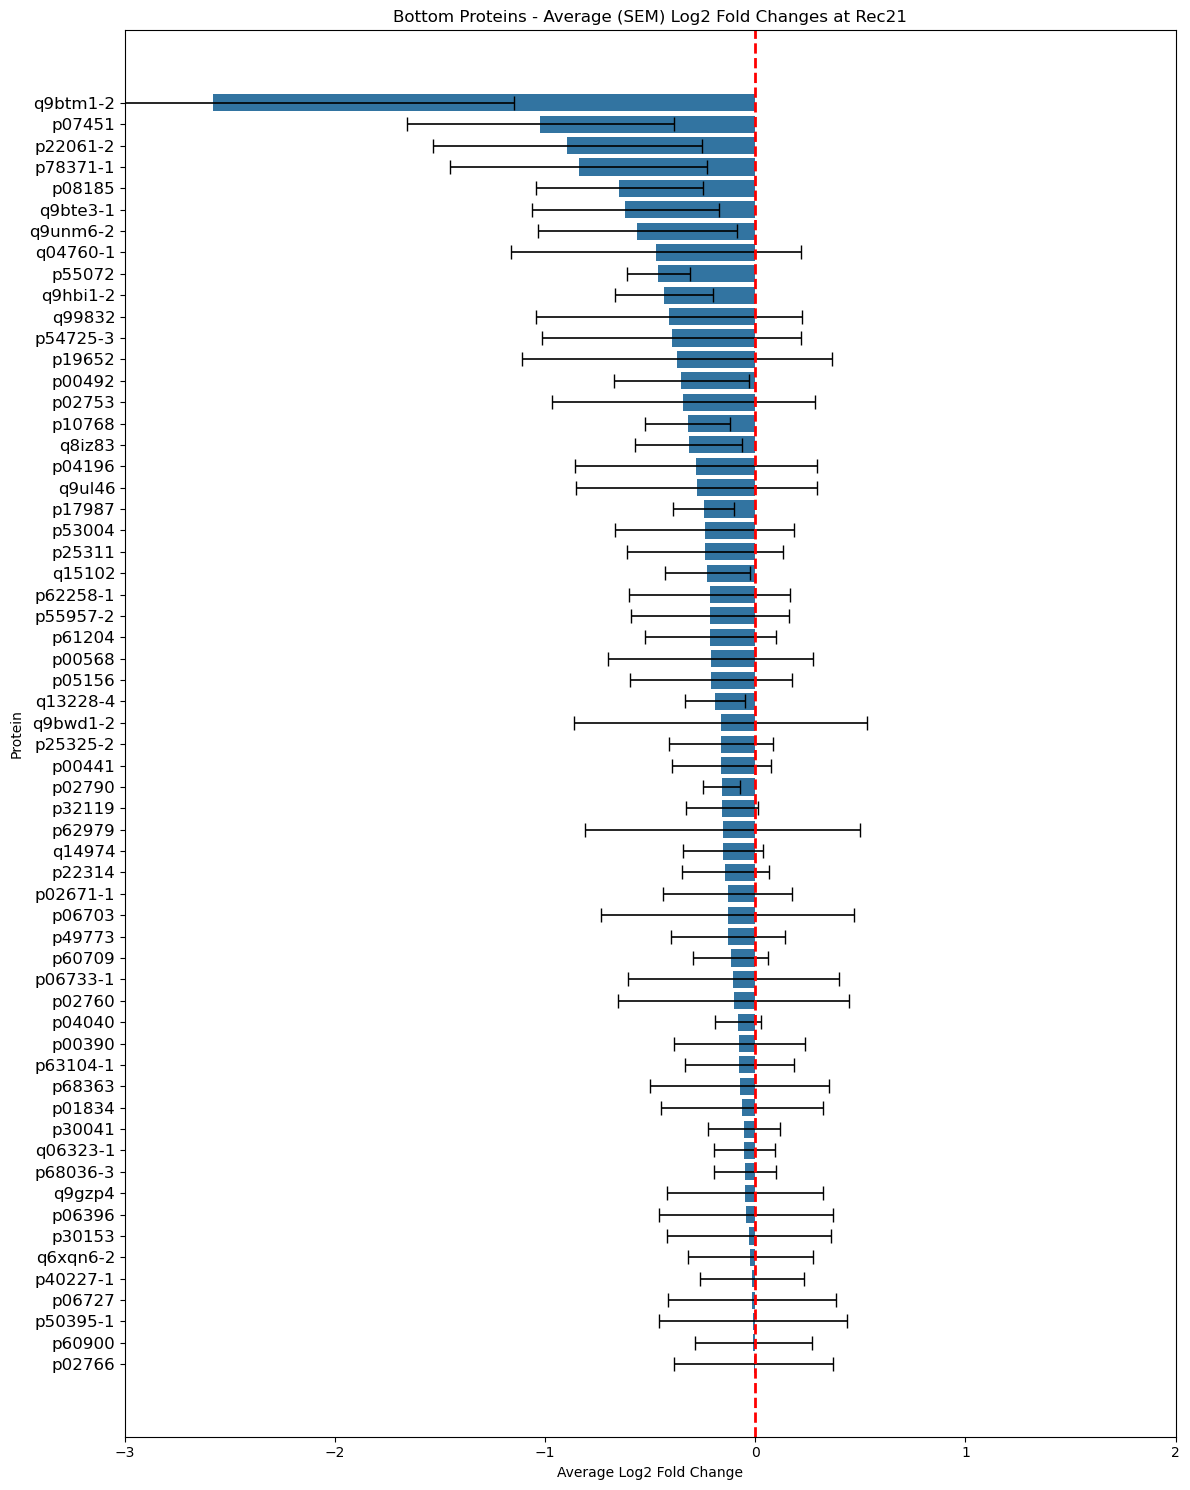

In [75]:
# Extract unique timepoints
unique_timepoints = ['Rec2', 'Rec21']

# Create a DataFrame to store average values and standard errors
new_rows_3tp = []


# Iterate over each protein column
for protein in protein_cols_3tp:
    # Iterate over each timepoint
    for timepoint in unique_timepoints:
        # Calculate the average and standard error for the current protein and timepoint
        subset = df_3tp_log2_fold_change[df_3tp_log2_fold_change['time']==timepoint]

        avg_val = subset[protein].mean()
        sem_val = subset[protein].sem()

        # Concatenate the result to the average DataFrame
        new_rows_3tp.append({
            'Protein': protein,
            'Time': timepoint,
            'Average': avg_val,
            'SEM': sem_val
        })

visuals_df_3tp = pd.DataFrame(new_rows_3tp)

# Filter to only downregulated proteins (Average <= 0), sort ascending (more negative at top)
down_3tp = visuals_df_3tp[visuals_df_3tp['Average']<=0].copy().reset_index(drop=True)
down_3tp.sort_values('Average', ascending=True, inplace=True)

# Create separate bar plots for each timepoint
for timepoint in unique_timepoints:
    subset = down_3tp[down_3tp['Time']==timepoint].copy()

    order = subset['Protein'].tolist()
    fig, ax = plt.subplots(figsize=(12, 15))
    
    ax = sns.barplot(
        data = subset,
        x = 'Average',
        y = 'Protein',
        order = order,
        dodge = 1.5,
        errorbar = None,
        ax = ax 
    )

    patches = ax.patches
    sem_vals = subset['SEM'].fillna(0).values

    for bar, sem in zip(patches, sem_vals):
        x = bar.get_width()                      # the Average value (bar length)
        y = bar.get_y() + bar.get_height() /2   # vertical center of the bar
        ax.errorbar(
            x=x,
            y=y,
            xerr=sem,
            fmt='none',      
            ecolor='black',
            capsize=5,
            elinewidth=1.2
        )

    # Formatting
    ax.set_xlim(-3, 2)
    ax.set_title(f'Bottom Proteins - Average (SEM) Log2 Fold Changes at {timepoint}')
    ax.set_xlabel('Average Log2 Fold Change')
    ax.set_ylabel('Protein')
    ax.tick_params(axis='y', labelsize=12)
    ax.axvline(x=0, ls='--', color='red', lw=2)

    plt.tight_layout()
    plt.show()


## Run statistics for 3-timepoints
- Friemdan test (non-parametric 1-way RM ANOVA)

- [Pingouin stats package](https://pingouin-stats.org/build/html/generated/pingouin.friedman.html)

 **pingouin.friedman(data=None, dv=None, within=None, subject=None, method='chisq')**


In [76]:
import pingouin as pg

In [77]:
# Get unique timepoints (not strictly needed for pg.friedman but fine to keep)
unique_timepoints = df_3tp_log2_fold_change['time'].unique()

friedman_results = []

for protein in protein_cols_3tp:
    results = pg.friedman(
        data=df_3tp_log2_fold_change,
        dv=protein,
        within='time',
        subject='subject_id',
        method='f'
    )

    # Ensure the index is numeric (fixes the KeyError: 0 issue)
    results = results.reset_index(drop=True)

    # Extract F and p values safely
    f_val = results.loc[0, 'F']
    p_val = results.loc[0, 'p-unc']

    friedman_results.append({
        'Protein': protein,
        'F-statistic': f_val,
        'P-value': p_val
    })

# Combine all results into one DataFrame
friedman_df = pd.DataFrame(friedman_results)

friedman_df.head()

,Protein,F-statistic,P-value
0,a0a0b4j1v0,2.166667,0.166918
1,a0a0c4dh25,2.909091,0.104633
2,o14818-1,0.125000,0.854730
3,o43681,0.391304,0.655284
4,o95445-1,0.533333,0.575561


In [78]:
friedman_df.sort_values(by='P-value', ascending=True, inplace=True)
friedman_df.head()

,Protein,F-statistic,P-value
16,p00747,23.4,0.000205
59,p04114,18.5,0.000527
135,p43487,8.0,0.009663
15,p00738,4.5,0.043742
27,p01768,4.5,0.043742


In [79]:
p_vals_3tp = friedman_df['P-value'].values.tolist()

reject, corrected_pvals_3tp = smm.fdrcorrection(p_vals_3tp,
                                                alpha=0.5,
                                                is_sorted=True)
friedman_df['reject'] = reject
friedman_df['p-adj'] = corrected_pvals_3tp

friedman_df.head()

,Protein,F-statistic,P-value,reject,p-adj
16,p00747,23.4,0.000205,True,0.042232
59,p04114,18.5,0.000527,True,0.054258
135,p43487,8.0,0.009663,False,0.663496
15,p00738,4.5,0.043742,False,0.683185
27,p01768,4.5,0.043742,False,0.683185


In [80]:
## adding protein descriptions

visuals_df_3tp_grouped = visuals_df_3tp.groupby(['Protein', 'Time'], as_index=False, observed=True)['Average'].mean()

three_tp_df = pd.merge(visuals_df_3tp, protein_names_df[['Accession','Description']],
                       left_on='Protein', right_on='Accession', how='left').drop(columns='Accession')

three_tp_df.head()

,Protein,Time,Average,SEM,Description
0,a0a0b4j1v0,Rec2,0.175381,0.286836,Immunoglobulin heavy variable 3-15 [OS=Homo sa...
1,a0a0b4j1v0,Rec21,0.276315,0.230404,Immunoglobulin heavy variable 3-15 [OS=Homo sa...
2,a0a0c4dh25,Rec2,0.262629,0.261402,immunoglobulin kappa variable 3D-20 [OS=Homo s...
3,a0a0c4dh25,Rec21,0.435112,0.244885,immunoglobulin kappa variable 3D-20 [OS=Homo s...
4,o14818-1,Rec2,0.129526,0.590065,Proteasome subunit alpha type-7 [OS=Homo sapiens]


In [81]:
friedman_cols = list(friedman_df.columns)

friedman_cols

['Protein', 'F-statistic', 'P-value', 'reject', 'p-adj']

In [82]:
friedman_df.head()

,Protein,F-statistic,P-value,reject,p-adj
16,p00747,23.4,0.000205,True,0.042232
59,p04114,18.5,0.000527,True,0.054258
135,p43487,8.0,0.009663,False,0.663496
15,p00738,4.5,0.043742,False,0.683185
27,p01768,4.5,0.043742,False,0.683185


In [83]:
three_tp_df_rec2 = three_tp_df[three_tp_df['Time']=='Rec2'].copy().reset_index()

three_tp_df_rec21 = three_tp_df[three_tp_df['Time']=='Rec21'].copy().reset_index()

three_tp_df_rec21.head()

,index,Protein,Time,Average,SEM,Description
0,1,a0a0b4j1v0,Rec21,0.276315,0.230404,Immunoglobulin heavy variable 3-15 [OS=Homo sa...
1,3,a0a0c4dh25,Rec21,0.435112,0.244885,immunoglobulin kappa variable 3D-20 [OS=Homo s...
2,5,o14818-1,Rec21,0.314291,0.373596,Proteasome subunit alpha type-7 [OS=Homo sapiens]
3,7,o43681,Rec21,0.269570,0.426063,ATPase ASNA1 [OS=Homo sapiens]
4,9,o95445-1,Rec21,0.293499,0.149621,apolipoprotein M [OS=Homo sapiens]


In [84]:
## Map average fold change for each protein timepoint to the friedman_df
rec2_protein_to_avg = three_tp_df_rec2.set_index('Protein')['Average']
rec21_protein_to_avg = three_tp_df_rec21.set_index('Protein')['Average']

friedman_df['Rec2_FC_avg'] = friedman_df['Protein'].map(rec2_protein_to_avg)
friedman_df['Rec21_FC_avg'] = friedman_df['Protein'].map(rec21_protein_to_avg)

friedman_df.head()

,Protein,F-statistic,P-value,reject,p-adj,Rec2_FC_avg,Rec21_FC_avg
16,p00747,23.4,0.000205,True,0.042232,0.523186,0.292824
59,p04114,18.5,0.000527,True,0.054258,0.460861,1.405284
135,p43487,8.0,0.009663,False,0.663496,-0.298727,0.382156
15,p00738,4.5,0.043742,False,0.683185,0.427489,0.937463
27,p01768,4.5,0.043742,False,0.683185,0.427811,0.333343


In [85]:
friedman_df.shape

(206, 7)

In [86]:
friedman_df['Protein'] = friedman_df['Protein'].str.lower()

In [87]:
friedman_df_final = pd.merge(friedman_df,protein_names_df[['Accession', 'Description']],
                             left_on='Protein', right_on='Accession', how='inner').drop(columns='Accession')

friedman_df_final.head()

,Protein,F-statistic,P-value,reject,p-adj,Rec2_FC_avg,Rec21_FC_avg,Description
0,p00747,23.4,0.000205,True,0.042232,0.523186,0.292824,Plasminogen [OS=Homo sapiens]
1,p04114,18.5,0.000527,True,0.054258,0.460861,1.405284,apolipoprotein B-100 [OS=Homo sapiens]
2,p43487,8.0,0.009663,False,0.663496,-0.298727,0.382156,Ran-specific GTPase-activating protein [OS=Hom...
3,p00738,4.5,0.043742,False,0.683185,0.427489,0.937463,Haptoglobin [OS=Homo sapiens]
4,p01768,4.5,0.043742,False,0.683185,0.427811,0.333343,Immunoglobulin heavy variable 3-30 [OS=Homo sa...


In [88]:
friedman_df_final.shape
## retained the appropriate len

(206, 8)

In [89]:
friedman_df_final.head()

,Protein,F-statistic,P-value,reject,p-adj,Rec2_FC_avg,Rec21_FC_avg,Description
0,p00747,23.4,0.000205,True,0.042232,0.523186,0.292824,Plasminogen [OS=Homo sapiens]
1,p04114,18.5,0.000527,True,0.054258,0.460861,1.405284,apolipoprotein B-100 [OS=Homo sapiens]
2,p43487,8.0,0.009663,False,0.663496,-0.298727,0.382156,Ran-specific GTPase-activating protein [OS=Hom...
3,p00738,4.5,0.043742,False,0.683185,0.427489,0.937463,Haptoglobin [OS=Homo sapiens]
4,p01768,4.5,0.043742,False,0.683185,0.427811,0.333343,Immunoglobulin heavy variable 3-30 [OS=Homo sa...


In [90]:
friedman_df_final['Test'] = 'Friedman'
friedman_df_final['time'] = '3_time'

friedman_df_final.head()

,Protein,F-statistic,P-value,reject,p-adj,Rec2_FC_avg,Rec21_FC_avg,Description,Test,time
0,p00747,23.4,0.000205,True,0.042232,0.523186,0.292824,Plasminogen [OS=Homo sapiens],Friedman,3_time
1,p04114,18.5,0.000527,True,0.054258,0.460861,1.405284,apolipoprotein B-100 [OS=Homo sapiens],Friedman,3_time
2,p43487,8.0,0.009663,False,0.663496,-0.298727,0.382156,Ran-specific GTPase-activating protein [OS=Hom...,Friedman,3_time
3,p00738,4.5,0.043742,False,0.683185,0.427489,0.937463,Haptoglobin [OS=Homo sapiens],Friedman,3_time
4,p01768,4.5,0.043742,False,0.683185,0.427811,0.333343,Immunoglobulin heavy variable 3-30 [OS=Homo sa...,Friedman,3_time


In [91]:
friedman_df_final.sort_values(by='P-value', ascending=True, inplace=True)

friedman_df_final_sig = friedman_df_final[friedman_df_final['P-value']<=0.1].copy().reset_index(drop=True)

friedman_df_final_sig

,Protein,F-statistic,P-value,reject,p-adj,Rec2_FC_avg,Rec21_FC_avg,Description,Test,time
0,p00747,23.4,0.000205,True,0.042232,0.523186,0.292824,Plasminogen [OS=Homo sapiens],Friedman,3_time
1,p04114,18.5,0.000527,True,0.054258,0.460861,1.405284,apolipoprotein B-100 [OS=Homo sapiens],Friedman,3_time
2,p43487,8.0,0.009663,False,0.663496,-0.298727,0.382156,Ran-specific GTPase-activating protein [OS=Hom...,Friedman,3_time
3,p00738,4.5,0.043742,False,0.683185,0.427489,0.937463,Haptoglobin [OS=Homo sapiens],Friedman,3_time
4,p01768,4.5,0.043742,False,0.683185,0.427811,0.333343,Immunoglobulin heavy variable 3-30 [OS=Homo sa...,Friedman,3_time
5,p07437,4.5,0.043742,False,0.683185,0.546998,0.324030,tubulin beta chain [OS=Homo sapiens],Friedman,3_time
6,p08697-1,4.5,0.043742,False,0.683185,0.359881,0.835004,Alpha-2-antiplasmin [OS=Homo sapiens],Friedman,3_time
7,p13671,3.8,0.063012,False,0.683185,0.494221,0.483459,Complement component c6 [OS=Homo sapiens],Friedman,3_time
8,p26447,3.8,0.063012,False,0.683185,1.571385,1.553040,Protein S100-A4 [OS=Homo sapiens],Friedman,3_time
9,q9btm1-2,3.8,0.063012,False,0.683185,-1.663003,-2.582123,Isoform 2 of Histone H2A.J [OS=Homo sapiens],Friedman,3_time


In [92]:
# unique_timepoints = df_3tp_log2_fold_change['time'].unique()

# friedman_results = []

# for protein in protein_cols_3tp:

#     results = pg.friedman(data=df_3tp_log2_fold_change, dv=protein, within='time', subject='subject_id', method='f')

#     results = results.reset_index(drop=True)
#     f_val = results.loc[0,'F']
#     p_val = results.loc[0,'p-unc']

#     friedman_results.append({
#         'Protein': protein,
#         'F-statistic': f_val,
#         'P-value': p_val
#     })

# friedman_df = pd.DataFrame(friedman_results)

# friedman_df

### Merge all significant proteins and their data into single df

In [93]:
# friedman_df_final_sig.head()
# all_FC_df.head()

In [94]:
all_FC_df.rename(columns={'corrected_p_value':'p-adj', 'AVG_FC':'AVG_FC_2tp'}, inplace=True)

all_FC_df['Test'] = 'Wilcoxon'

all_FC_df.head()

,Protein,Wilcoxon Statistic,P-value,reject,p-adj,AVG_FC_2tp,Accession,Description,time,Test
0,p00747,0.0,0.016,False,0.96976,0.523186,p00747,Plasminogen [OS=Homo sapiens],MID,Wilcoxon
1,p01023,3.0,0.078,False,0.96976,0.325703,p01023,alpha-2-macroglobulin [OS=Homo sapiens],MID,Wilcoxon
2,p02730,3.0,0.078,False,0.96976,0.252418,p02730,Band 3 anion transport protein [OS=Homo sapiens],MID,Wilcoxon
3,p02774-3,3.0,0.078,False,0.96976,0.316248,p02774-3,Isoform 3 of Vitamin D-binding protein [OS=Hom...,MID,Wilcoxon
4,p04632,2.0,0.094,False,0.96976,0.218820,p04632,Calpain small subunit 1 [OS=Homo sapiens],MID,Wilcoxon


In [95]:
final_df = pd.concat([all_FC_df, friedman_df_final_sig], ignore_index=True, sort=False)
final_df

,Protein,Wilcoxon Statistic,P-value,reject,p-adj,AVG_FC_2tp,Accession,Description,time,Test,F-statistic,Rec2_FC_avg,Rec21_FC_avg
0,p00747,0.0,0.016000,False,0.969760,0.523186,p00747,Plasminogen [OS=Homo sapiens],MID,Wilcoxon,NaN,NaN,NaN
1,p01023,3.0,0.078000,False,0.969760,0.325703,p01023,alpha-2-macroglobulin [OS=Homo sapiens],MID,Wilcoxon,NaN,NaN,NaN
2,p02730,3.0,0.078000,False,0.969760,0.252418,p02730,Band 3 anion transport protein [OS=Homo sapiens],MID,Wilcoxon,NaN,NaN,NaN
3,p02774-3,3.0,0.078000,False,0.969760,0.316248,p02774-3,Isoform 3 of Vitamin D-binding protein [OS=Hom...,MID,Wilcoxon,NaN,NaN,NaN
4,p04632,2.0,0.094000,False,0.969760,0.218820,p04632,Calpain small subunit 1 [OS=Homo sapiens],MID,Wilcoxon,NaN,NaN,NaN
5,p05155-3,2.0,0.047000,False,0.969760,0.993958,p05155-3,Isoform 3 of Plasma protease C1 inhibitor [OS=...,MID,Wilcoxon,NaN,NaN,NaN
6,p05543,3.0,0.078000,False,0.969760,0.414385,p05543,thyroxine-binding globulin [OS=Homo sapiens],MID,Wilcoxon,NaN,NaN,NaN
7,p05546,1.0,0.031000,False,0.969760,0.288005,p05546,Heparin cofactor 2 [OS=Homo sapiens],MID,Wilcoxon,NaN,NaN,NaN
8,p0c0l5,3.0,0.078000,False,0.969760,0.198523,p0c0l5,Complement C4-B [OS=Homo sapiens],MID,Wilcoxon,NaN,NaN,NaN
9,p13671,2.0,0.047000,False,0.969760,0.494221,p13671,Complement component c6 [OS=Homo sapiens],MID,Wilcoxon,NaN,NaN,NaN


In [96]:
final_df.to_excel('merged_sig_FC_proteins 10.20.25.xlsx')

## Concluding Remarks

- There were 16 proteins significantly altered from BL to rec 2 (Wilcoxon)
- There were 19 proteins significantly altered from BL to rec21 (Wilcoxon)
- There were 19 proteins significantly altered from BL to rec2 to rec21 (Friedman)

**Next Steps:** 
- Take these proteins, remove duplicates, and add proteins that had the same directional change into STRING database to identify shared biological pathways via GO terminology